# redMaPPer blind mode on DR11

The figures of the documentation page *redMaPPer blind mode on DR11*, made from the DR11
south production catalogue of rema (blind mode). Each section reproduces figures of the
redMaPPer papers (Rykoff et al. 2014, 2016; Kluge et al. 2024) and of later papers that
validate redMaPPer catalogues; the captions on the documentation page give the references.

The first cells set the paths, the figure style and the shared helpers. `prepare.py` then
reduces the catalogues (2.5 million clusters, 61 million members per part) and the DR11
randoms to the small tables and HEALPix maps that the figures read; it is skipped when its
products are up to date.

This notebook is assembled by `docs/notebooks/build_notebooks.py redmapper` from the scripts
in `docs/figures/redmapper_dr11` (`common.py`, `prepare.py`, `fig_redsequence.py`, `fig_redshifts.py`, `fig_richness.py`, `fig_abundance.py`, `fig_centering.py`, `fig_external.py`, `fig_members.py`), which also
write the figures of the documentation page. Run as scripts, they save PNG files; here the
figures are shown inline.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from matplotlib.colors import LinearSegmentedColormap  # noqa: E402

os.environ.setdefault("JAX_PLATFORMS", "cpu")        # only the red-sequence model uses JAX here

# The two directories of the notebooks, from two environment variables:
#   REMA_DATA  shared, read only: the DR11 south directory (randoms/) with the rema production run
#              and the external catalogues in rema/. Default: the DR11 data system at CC-IN2P3
#              when /sps is mounted, else ~/data/legacysurvey/dr11/south.
#   REMA_WORK  yours, writable: everything the notebooks write. Default: ~/rema_work.
CC = Path("/sps/lsst/datasets/desi/legacysurveys/dr11/south")
REMA_DATA = Path(os.environ.get("REMA_DATA", CC if CC.exists() else Path.home() / "data" / "legacysurvey" / "dr11" / "south"))
REMA_WORK = Path(os.environ.get("REMA_WORK", Path.home() / "rema_work"))
if not REMA_DATA.is_dir():
    raise SystemExit(f"REMA_DATA = {REMA_DATA} not found: set REMA_DATA to the DR11 south directory")

# In REMA_DATA: the two parts of the production run (they meet at RA 0 and 240 deg and at
# Dec -85 deg), one randoms file and the public cluster catalogues.
PRODUCTS = REMA_DATA / "rema"
RUNS = [PRODUCTS / "rema_dr11_v0.2.0_ra0-240", PRODUCTS / "rema_dr11_v0.2.0_ra240-360"]
CALIB = RUNS[0] / "calib" / "calib.fits"
RANDOMS = REMA_DATA / "randoms" / "randoms-south-1-0.fits"
EXTERNAL = PRODUCTS / "external"
# In REMA_WORK: the reduced tables and maps of prepare.py.
WORK = REMA_WORK / "redmapper"
# Figures are written next to the scripts when they run as scripts; the notebook shows them.
try:
    FIGDIR = Path(__file__).resolve().parent
except NameError:
    FIGDIR = None
try:
    WORK.mkdir(parents=True, exist_ok=True)
except OSError:
    pass
if not os.access(WORK, os.W_OK):
    raise SystemExit(f"cannot write to REMA_WORK = {REMA_WORK}: set REMA_WORK to a directory of yours")

Figure style: the palette of the other documentation figures (categorical colours in a fixed
order, a one-hue blue ramp for magnitudes, blue/red around a grey midpoint for contrasts),
hairline grids and no top or right spines.

In [2]:
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN]
SURFACE, INK, INK2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#a3a29d"
RAMP = LinearSegmentedColormap.from_list("ramp", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
DIVERGE = LinearSegmentedColormap.from_list("diverge", ["#1c5cab", "#86b6ef", "#f0efec", "#ef9a99", "#b02f2f"])
RAMP.set_bad(SURFACE)
DIVERGE.set_bad(SURFACE)
DPI = 120

plt.rcParams.update({
    "figure.dpi": 100, "figure.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": INK2, "axes.labelcolor": INK, "axes.grid": True,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "font.size": 9, "axes.titlesize": 9, "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6})


def png_bytes(fig, dpi):
    """The figure as a PNG with a 256-colour palette (2-3 times smaller, no visible change)."""
    import io

    from PIL import Image

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    img = Image.open(io.BytesIO(buf.getvalue())).convert("RGB")
    out = io.BytesIO()
    img.quantize(colors=256, method=Image.Quantize.MEDIANCUT, dither=Image.Dither.NONE).save(out, "png", optimize=True)
    return out.getvalue()


def save(fig, name):
    """Write ``<name>.png`` next to the scripts (script run) or show the figure (notebook)."""
    if FIGDIR is not None:
        (FIGDIR / f"{name}.png").write_bytes(png_bytes(fig, DPI))
        print(f"wrote {name}.png")
    else:
        from IPython.display import Image, display

        display(Image(data=png_bytes(fig, 90)))
    plt.close(fig)


def plain_log_ticks(ax, axis="x", subs=(1.0, 2.0, 5.0)):
    """Plain numbers (1, 2, 5, 10, ...) on a log axis instead of powers of ten."""
    from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_locator(LogLocator(subs=subs))
    a.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    a.set_minor_formatter(NullFormatter())


def panel_label(ax, text):
    ax.text(0.02, 0.97, text, transform=ax.transAxes, ha="left", va="top", fontsize=8, color=INK)

Numbers that the documentation page quotes next to the literature values are collected with
`record()` into `values.json` in the work directory (`make_all.py` turns them into a table).

In [3]:
VALUES_FILE = WORK / "values.json"


def record(key, value):
    """Store a number (or a short list) quoted by the documentation page."""
    vals = json.loads(VALUES_FILE.read_text()) if VALUES_FILE.exists() else {}
    vals[key] = value if isinstance(value, (str, list, dict)) else float(value)
    VALUES_FILE.write_text(json.dumps(vals, indent=1, sort_keys=True))

Literature values used as references in the figures (read from the papers' tables and text;
values marked "read off" were read from their figures).

In [4]:
LIT = {
    # Rykoff et al. (2014), SDSS DR8: lambda/S > 20, 0.08 < z < 0.55.
    "R14_N": 25236, "R14_area": 10400.0,
    "R14_sigz": 0.01, "R14_out4": 0.01,
    # comoving density at z < 0.35 for lambda/S > 10, 20, 40 [h^3 Mpc^-3] (Fig. 18, read off)
    "R14_nV": {10: 4.5e-5, 20: 1.15e-5, 40: 2.5e-6},
    # Rykoff et al. (2016): SDSS DR8 v6.3 and DES SVA1.
    "R16_dr8_N": 26111, "R16_dr8_area": 10134.0, "R16_sva_N": 787, "R16_sva_area": 116.0,
    "R16_pcen": 0.82, "R16_rho0": 0.78, "R16_rho0_err": 0.11, "R16_sigma1": 0.31,
    # Kluge et al. (2024), LS DR10 south grz, lambda_norm > 16, z < z_vlim.
    "K24_N_grz": 112609, "K24_area_grz": 19342.0, "K24_N_griz": 91790, "K24_area_griz": 15326.0,
    "K24_lam_ratio_desy1": 0.79, "K24_snorm_griz": 1.039,
    # bias and empirical uncertainty of z_lambda in z_spec bins (Table 5)
    "K24_zbins": [(0.0, 0.05), (0.05, 0.4), (0.4, 0.8), (0.8, 1.2)],
    "K24_bias": [0.0040, 0.0004, -0.0041, -0.0178],
    "K24_dz_hi": [0.0093, 0.0062, 0.0095, 0.0153], "K24_dz_lo": [-0.0078, -0.0061, -0.0110, -0.0242],
    # log10 lambda_norm = a log10 sigma_v + b (Fig. 18)
    "K24_lam_sig": (2.401, -5.074),
    # DES Y1 redMaPPer (McClintock et al. 2019): 6729 clusters lambda > 20 over 1437 deg2
    "DESY1_N": 6729, "DESY1_area": 1437.0,
}


def ider_chitham_lambda(lam_sdss, z):
    """Ider Chitham et al. (2020), Eq. 1: Legacy Surveys lambda from SDSS DR8 lambda."""
    return lam_sdss / (1.04 + 0.17 * np.exp(5.4 * (z - 0.36)))

Shared helpers: cosmology (that of the calibration), statistics and matching.

In [5]:
from astropy.coordinates import SkyCoord  # noqa: E402
from astropy.cosmology import FlatLambdaCDM  # noqa: E402
import astropy.units as u  # noqa: E402

COSMO = FlatLambdaCDM(H0=70.0, Om0=0.3)        # cosmology section of the calibration
H = 0.7
C_KMS = 299792.458
CALIB_BOXES = [(160.0, 180.0, -10.0, 10.0), (190.0, 210.0, -10.0, 10.0)]   # spec-z training area


def nmad(x):
    x = np.asarray(x)
    return 1.4826 * np.median(np.abs(x - np.median(x))) if x.size else np.nan


def binned(x, y, edges, min_n=10):
    """Per bin of x: centre, count, median, 16th/84th percentiles, mean, NMAD of y."""
    out = {k: [] for k in ("x", "n", "med", "p16", "p84", "mean", "nmad", "std")}
    idx = np.digitize(x, edges) - 1
    for k in range(len(edges) - 1):
        v = y[idx == k]
        out["x"].append(0.5 * (edges[k] + edges[k + 1]))
        out["n"].append(v.size)
        ok = v.size >= min_n
        out["med"].append(np.median(v) if ok else np.nan)
        out["p16"].append(np.percentile(v, 16) if ok else np.nan)
        out["p84"].append(np.percentile(v, 84) if ok else np.nan)
        out["mean"].append(v.mean() if ok else np.nan)
        out["nmad"].append(nmad(v) if ok else np.nan)
        out["std"].append(v.std() if ok else np.nan)
    return {k: np.asarray(v) for k, v in out.items()}


def nearest(ra1, dec1, ra2, dec2):
    """For each position 1, the index of the nearest position 2 and the separation [arcmin]."""
    c1 = SkyCoord(np.asarray(ra1) * u.deg, np.asarray(dec1) * u.deg)
    c2 = SkyCoord(np.asarray(ra2) * u.deg, np.asarray(dec2) * u.deg)
    j, sep, _ = c1.match_to_catalog_sky(c2)
    return j, sep.arcmin


def match_within(ra1, dec1, z1, ra2, dec2, z2, radius_arcmin, dz_max=None, rank2=None):
    """One-to-one matches: each object 1 takes the best-ranked object 2 within ``radius_arcmin``
    (and |dz|/(1+z1) < dz_max); ``rank2`` (higher is better, e.g. lambda) defaults to closeness.
    Returns index arrays (i1, i2)."""
    c1 = SkyCoord(np.asarray(ra1) * u.deg, np.asarray(dec1) * u.deg)
    c2 = SkyCoord(np.asarray(ra2) * u.deg, np.asarray(dec2) * u.deg)
    i1, i2, sep, _ = c2.search_around_sky(c1, radius_arcmin * u.arcmin)
    ok = np.ones(i1.size, bool)
    if dz_max is not None:
        ok = np.abs(np.asarray(z2)[i2] - np.asarray(z1)[i1]) / (1 + np.asarray(z1)[i1]) < dz_max
    i1, i2, sep = i1[ok], i2[ok], sep.arcmin[ok]
    score = -sep if rank2 is None else np.asarray(rank2)[i2] - 1e-6 * sep
    order = np.lexsort((-score, i1))
    i1, i2 = i1[order], i2[order]
    used1, used2, a, b = set(), set(), [], []
    for p, q in zip(i1, i2):
        if p in used1 or q in used2:
            continue
        used1.add(p)
        used2.add(q)
        a.append(p)
        b.append(q)
    return np.asarray(a, int), np.asarray(b, int)


def match_physical(ra1, dec1, z1, ra2, dec2, z2, rmax=1.0, dz_max=0.05, rank2=None):
    """One-to-one matches within a projected distance ``rmax`` [h^-1 Mpc] at z1 and
    |z2 - z1|/(1+z1) < dz_max; each object 1 takes the best-ranked free object 2 (``rank2``, higher
    is better; default the closest). Returns (i1, i2, projected distance [h^-1 Mpc])."""
    z1, z2 = np.asarray(z1, np.float64), np.asarray(z2, np.float64)
    ra2, dec2 = np.asarray(ra2), np.asarray(dec2)
    idx1 = np.flatnonzero(np.isfinite(z1) & (z1 > 0.01))
    scale = np.radians(1.0 / 60.0) * COSMO.angular_diameter_distance(z1[idx1]).value * H   # h^-1 Mpc per arcmin
    A, B, D = [], [], []
    # Search in slices of z1, each with its own angular radius and only the candidates in z.
    edges = np.unique(np.quantile(z1[idx1], np.linspace(0, 1, 21))) if idx1.size else np.array([])
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = np.flatnonzero((z1[idx1] >= lo) & (z1[idx1] <= hi))
        cand = np.flatnonzero(np.abs(z2 - 0.5 * (lo + hi)) < 0.5 * (hi - lo) + dz_max * (1 + hi))
        if s.size == 0 or cand.size == 0:
            continue
        c1 = SkyCoord(np.asarray(ra1)[idx1[s]] * u.deg, np.asarray(dec1)[idx1[s]] * u.deg)
        c2 = SkyCoord(ra2[cand] * u.deg, dec2[cand] * u.deg)
        a, b, sep, _ = c2.search_around_sky(c1, rmax / scale[s].min() * u.arcmin)
        d = sep.arcmin * scale[s][a]
        a, b = s[a], cand[b]
        ok = (d < rmax) & (np.abs(z2[b] - z1[idx1][a]) / (1 + z1[idx1][a]) < dz_max)
        A.append(a[ok])
        B.append(b[ok])
        D.append(d[ok])
    if not A:
        return np.zeros(0, int), np.zeros(0, int), np.zeros(0)
    a, b, d = np.concatenate(A), np.concatenate(B), np.concatenate(D)
    score = -d if rank2 is None else np.asarray(rank2)[b] - 1e-6 * d
    order = np.lexsort((-score, a))
    used1, used2, out = set(), set(), []
    for p in order:
        if a[p] in used1 or b[p] in used2:
            continue
        used1.add(a[p])
        used2.add(b[p])
        out.append(p)
    out = np.asarray(out, int)
    return idx1[a[out]], b[out], d[out]


def in_calib(ra, dec):
    ra, dec = np.asarray(ra), np.asarray(dec)
    out = np.zeros(ra.size, bool)
    for r0, r1, d0, d1 in CALIB_BOXES:
        out |= (ra >= r0) & (ra < r1) & (dec >= d0) & (dec < d1)
    return out

Readers of the products of `prepare.py`: each table is a directory of `.npy` columns, memory
mapped, so that the figures load only what they use.

In [6]:
def load(name, columns=None):
    """A reduced table of prepare.py (clusters, members, maps, or external/<catalogue>)."""
    d = WORK / name
    if not d.exists():
        raise FileNotFoundError(f"{name}: run prepare.py first")
    cols = columns or sorted(p.stem for p in d.glob("*.npy"))
    return {c: np.load(d / f"{c}.npy", mmap_mode="r") for c in cols}


def meta():
    return json.loads((WORK / "meta.json").read_text())


def external(name):
    """A public cluster catalogue normalised by prepare.py, or None (with a note) if absent."""
    d = WORK / "external" / name
    if not d.exists():
        print(f"{name}: not available, skipped")
        return None
    return {p.stem: np.load(p) for p in d.glob("*.npy")}

Sky maps: HEALPix (NEST) values drawn on a Mollweide projection centred on RA = 120 deg, RA
increasing to the left.

In [7]:
import healpy as hp  # noqa: E402

RA_CENTRE = 120.0


def sky_axes(fig, rect=111):
    ax = fig.add_subplot(rect, projection="mollweide")
    ax.grid(True, color=GRID, lw=0.5)
    ticks = np.arange(-150, 181, 60)
    ax.set_xticks(np.radians(ticks))
    ax.set_xticklabels([f"{(RA_CENTRE - t) % 360:.0f}°" for t in ticks], fontsize=7, color=INK2)
    ax.tick_params(axis="y", labelsize=7, colors=INK2)
    return ax


def sky_image(ax, nside, pix, values, cmap=RAMP, vmin=None, vmax=None, nx=1440, ny=720):
    """Rasterise a partial NEST map (pixels ``pix`` with ``values``) on a Mollweide axis."""
    full = np.full(hp.nside2npix(nside), np.nan)
    full[np.asarray(pix)] = values
    lon = np.linspace(-np.pi, np.pi, nx)
    lat = np.linspace(-np.pi / 2, np.pi / 2, ny)
    LON, LAT = np.meshgrid(lon, lat)
    ra = (RA_CENTRE - np.degrees(LON)) % 360.0
    p = hp.ang2pix(nside, ra, np.degrees(LAT), lonlat=True, nest=True)
    img = np.ma.masked_invalid(full[p])
    return ax.pcolormesh(LON, LAT, img, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)


def sky_xy(ra, dec):
    """Mollweide axis coordinates [rad] of RA, Dec [deg]."""
    x = np.radians(RA_CENTRE - np.asarray(ra))
    x = (x + np.pi) % (2 * np.pi) - np.pi
    return x, np.radians(np.asarray(dec))

## Reduced tables and maps (`prepare.py`)

The production catalogue is read once and reduced to the columns the figures use. The DR11
randoms give the footprint of the run, cut as the galaxies were (`MASKBITS`, at least one
exposure in g, r, i and z, E(B−V) < 0.2), to |b| ≥ 15° and to the own boxes of the regions
that finished. Each step is skipped when its products are newer than its inputs.

In [8]:
from rema.calibration import Calibration
from rema.config import EXTINCTION_DECAM
from rema.io.tables import read_table
from rema.model.profiles import MStar, maxmag_from_mstar
from rema.pipeline import galactic_latitude, read_plan
from rema.sky.maps import good_randoms

FORCE = "--force" in sys.argv[1:] if FIGDIR is not None else False
NSIDE = 256
CAL = Calibration.read(CALIB)
CFG = CAL.config
BANDS = [b.upper() for b in CFG.survey.bands]
DENSITY = CFG.mask.randoms_density                    # randoms per deg2 in one DR11 randoms file
PARTS = [k for k, run in enumerate(RUNS) if (run / "clusters_dr11.fits").exists()]
print("parts present:", [RUNS[k].name for k in PARTS])


def signature(paths):
    return [[str(Path(p).name), os.path.getsize(p), int(os.path.getmtime(p))] for p in paths]


def write_columns(name, cols):
    d = WORK / name
    d.mkdir(parents=True, exist_ok=True)
    for old in d.glob("*.npy"):
        old.unlink()
    for k, v in cols.items():
        np.save(d / f"{k}.npy", np.ascontiguousarray(v))


def up_to_date(key, sig):
    m = json.loads((WORK / "meta.json").read_text()) if (WORK / "meta.json").exists() else {}
    return not FORCE and m.get(key) == sig


def update_meta(**kw):
    m = json.loads((WORK / "meta.json").read_text()) if (WORK / "meta.json").exists() else {}
    m.update(kw)
    (WORK / "meta.json").write_text(json.dumps(m, indent=1))

parts present: ['rema_dr11_v0.2.0_ra0-240', 'rema_dr11_v0.2.0_ra240-360']


### The footprint of each part

The own boxes of the regions that finished (the region plan minus the regions listed as
missing in the QA file): a random point belongs to the run if it falls in one of them.

In [9]:
OWN = {}
for k in PARTS:
    plan, _ = read_plan(RUNS[k] / "regions.fits")
    qa = json.loads((RUNS[k] / "clusters_dr11_qa.json").read_text())
    done = ~np.isin(plan["REGION_ID"], qa["missing"])
    OWN[k] = np.stack([plan[f"OWN_{a}"][done] for a in ("RA0", "RA1", "DEC0", "DEC1")], axis=1)
    print(f"{RUNS[k].name}: {done.sum()} of {done.size} regions done, missing {qa['missing']}")


def part_of(ra, dec):
    """Part whose finished own boxes contain each position (-1 for none)."""
    out = np.full(ra.size, -1, np.int8)
    for k, boxes in OWN.items():
        for r0, r1, d0, d1 in boxes:
            rr = (ra - r0) % 360.0
            inside = (rr < (r1 - r0)) & (dec >= d0) & (dec < d1)
            out[inside] = k
    return out

rema_dr11_v0.2.0_ra0-240: 191 of 198 regions done, missing [117, 156, 161, 164, 166, 167, 175]
rema_dr11_v0.2.0_ra240-360: 79 of 94 regions done, missing [10, 20, 21, 39, 52, 55, 58, 63, 67, 77, 88, 90, 91, 92, 93]


### Depth and z_vlim maps from the randoms

Per HEALPix pixel (NSIDE 256, 0.05 deg²): the number of randoms in the run (its area at 2500
randoms per deg²), the mean 10σ galaxy depth in each band corrected for Galactic extinction,
the mean E(B−V) and z-band PSF size, and the fraction of observed randoms removed by the mask
bits. As in Kluge et al. (2024, Fig. B.3), z_vlim is the redshift at which a 0.2 L* galaxy,
m*(z) + 1.75 in the reference band (z), reaches the 10σ depth.

In [10]:
MSTAR = MStar(CFG.model.mstar)
ZGRID = np.asarray(MSTAR.z)
MLIM = np.asarray(maxmag_from_mstar(np.asarray(MSTAR.m), CFG.model.lval_reference))   # m* + 1.75


def zvlim_of(depth10):
    return np.interp(depth10, MLIM, ZGRID, left=np.nan, right=ZGRID[-1])


def read_randoms_chunks(path, columns, chunk=4_000_000):
    """Yield dicts of columns of a randoms file, chunk by chunk."""
    try:
        import fitsio

        with fitsio.FITS(str(path)) as f:
            n = f[1].get_nrows()
            for lo in range(0, n, chunk):
                d = f[1].read(columns=columns, rows=np.arange(lo, min(n, lo + chunk)))
                yield {c: d[c].astype(d[c].dtype.newbyteorder("=")) for c in columns}
    except ImportError:
        from astropy.io import fits

        with fits.open(path, memmap=True) as h:
            data = h[1].data
            for lo in range(0, len(data), chunk):
                sl = slice(lo, lo + chunk)
                yield {c: np.asarray(data[c][sl]).astype(data[c].dtype.newbyteorder("=")) for c in columns}


maps_sig = {"randoms": signature([RANDOMS]), "parts": [RUNS[k].name for k in PARTS],
            "qa": signature([RUNS[k] / "clusters_dr11_qa.json" for k in PARTS])}
if up_to_date("maps", maps_sig):
    print("maps: up to date")
else:
    t0 = time.time()
    cols = ["RA", "DEC", "MASKBITS", "EBV"] + [f"NOBS_{b}" for b in BANDS] + \
           [f"GALDEPTH_{b}" for b in BANDS] + ["PSFSIZE_Z"]
    npix = hp.nside2npix(NSIDE)
    acc = {k: np.zeros(npix) for k in ["N_ALL", "N_OBS", "N_RUNOBS", "N_RUN", "EBV", "PSFSIZE_Z"]
           + [f"N_RUN_P{k}" for k in (0, 1)] + [f"DEPTH_{b}" for b in BANDS]}
    reject = np.int64(sum(1 << int(b) for b in CFG.survey.maskbits_reject))
    nread = 0
    for r in read_randoms_chunks(RANDOMS, cols):
        ra, dec = r["RA"].astype(np.float64), r["DEC"].astype(np.float64)
        pix = hp.ang2pix(NSIDE, ra, dec, lonlat=True, nest=True)
        observed = np.ones(ra.size, bool)
        for b in BANDS:
            observed &= (r[f"NOBS_{b}"] >= CFG.survey.nobs_min) & (r[f"GALDEPTH_{b}"] > 0)
        good = good_randoms(r, CFG)
        part = part_of(ra, dec)
        sky = (np.abs(galactic_latitude(ra, dec)) >= 15.0) & (r["EBV"] < CFG.survey.ebv_max) & (part >= 0)
        run = good & sky
        acc["N_ALL"] += np.bincount(pix, minlength=npix)
        acc["N_OBS"] += np.bincount(pix, weights=observed, minlength=npix)
        acc["N_RUNOBS"] += np.bincount(pix, weights=observed & sky, minlength=npix)
        acc["N_RUN"] += np.bincount(pix, weights=run, minlength=npix)
        for k in (0, 1):
            acc[f"N_RUN_P{k}"] += np.bincount(pix, weights=run & (part == k), minlength=npix)
        w = run.astype(float)
        for b in BANDS:
            m10 = 22.5 - 2.5 * np.log10(10.0 / np.sqrt(np.where(run, r[f"GALDEPTH_{b}"], 1.0)))
            m10 -= EXTINCTION_DECAM[b.lower()] * r["EBV"]
            acc[f"DEPTH_{b}"] += np.bincount(pix, weights=np.where(run, m10, 0.0), minlength=npix)
        acc["EBV"] += np.bincount(pix, weights=w * r["EBV"], minlength=npix)
        acc["PSFSIZE_Z"] += np.bincount(pix, weights=w * r["PSFSIZE_Z"], minlength=npix)
        nread += ra.size
        print(f"  {nread / 1e6:.0f} M randoms read ({time.time() - t0:.0f} s)", end="\r")
    print()
    keep = np.flatnonzero(acc["N_RUN"] > 0)
    n = acc["N_RUN"][keep]
    maps = {"PIX": keep.astype(np.int64), "N_ALL": acc["N_ALL"][keep], "N_RUN": n,
            "AREA": n / DENSITY,
            "MASKED_FRAC": 1.0 - n / np.maximum(acc["N_RUNOBS"][keep], 1),
            "EBV": acc["EBV"][keep] / n, "PSFSIZE_Z": acc["PSFSIZE_Z"][keep] / n}
    for k in (0, 1):
        maps[f"AREA_P{k}"] = acc[f"N_RUN_P{k}"][keep] / DENSITY
    for b in BANDS:
        maps[f"DEPTH_{b}10"] = acc[f"DEPTH_{b}"][keep] / n
    maps["ZVLIM"] = zvlim_of(maps["DEPTH_Z10"])
    # The 5 sigma depth (rema's S/N >= 5 cut in the reference band) for comparison.
    maps["ZVLIM5"] = zvlim_of(maps["DEPTH_Z10"] + 2.5 * np.log10(2.0))
    write_columns("maps", maps)
    area = {RUNS[k].name: float(maps[f"AREA_P{k}"].sum()) for k in PARTS}
    update_meta(maps=maps_sig, area=area, nside=NSIDE, density=DENSITY)
    print(f"maps: {keep.size} pixels, run area {sum(area.values()):.0f} deg2 {area} "
          f"({time.time() - t0:.0f} s)")

  66 M randoms read (440 s)
maps: 392095 pixels, run area 18491 deg2 {'rema_dr11_v0.2.0_ra0-240': 13067.7788, 'rema_dr11_v0.2.0_ra240-360': 5423.0455999999995} (440 s)


### Clusters

All clusters of the parts present, with the part, the region (`MEM_MATCH_ID >> 32`), the
Galactic latitude, a flag for the calibration area (whose spectroscopic redshifts trained the
red-sequence model), the distance to the seams between the parts (RA 0° and 240°, Dec −85°)
and the depth-map values at the cluster position.

In [11]:
CL_COLS = ["RA", "DEC", "LAMBDA", "LAMBDA_E", "Z_LAMBDA", "Z_LAMBDA_E", "Z_LAMBDA_RAW", "R_LAMBDA",
           "SCALEVAL", "MASKFRAC", "NCENT_GOOD", "REFMAG", "ZRED", "ZRED_E", "ZRED_CHISQ", "MEM_MATCH_ID",
           "NSPEC", "N_MEMBERS", "SPEC_Z_BOOT", "SPEC_ZERR_BOOT", "VDISP_BOOT", "VDISP_ERR_BOOT",
           "VDISP_FLAG", "CG_SPEC_Z", "BEST_Z", "LNLAMLIKE", "P_CEN", "ID_CENT", "RA_CENT", "DEC_CENT",
           "PZBINS", "PZ"]


def seam_distance(ra, dec):
    """Angular distance [deg] to the seams of the two parts: RA = 0 and 240 deg, Dec = -85 deg."""
    d = np.full(ra.size, np.inf)
    for ra0 in (0.0, 240.0):
        dra = np.radians((ra - ra0 + 180.0) % 360.0 - 180.0)
        d = np.minimum(d, np.degrees(np.arcsin(np.minimum(1.0, np.abs(np.sin(dra)) * np.cos(np.radians(dec))))))
    return np.minimum(d, np.abs(dec + 85.0))


cl_sig = signature([RUNS[k] / "clusters_dr11.fits" for k in PARTS])
if up_to_date("clusters", {"cat": cl_sig, "maps": maps_sig}):
    print("clusters: up to date")
else:
    t0 = time.time()
    parts = []
    for k in PARTS:
        c = read_table(RUNS[k] / "clusters_dr11.fits", columns=CL_COLS, hdu="CLUSTERS")
        c["PART"] = np.full(c["RA"].size, k, np.int8)
        parts.append(c)
    cl = {c: np.concatenate([q[c] for q in parts]) for c in parts[0]}
    cl["ID_CG"] = cl.pop("ID_CENT")[:, 0]
    cl["REGION"] = (cl["MEM_MATCH_ID"] >> 32).astype(np.int32)
    cl["GLAT"] = galactic_latitude(cl["RA"], cl["DEC"]).astype(np.float32)
    cl["IN_CALIB"] = in_calib(cl["RA"], cl["DEC"])
    cl["SEAM_DIST"] = seam_distance(cl["RA"], cl["DEC"]).astype(np.float32)
    mp = load("maps")
    pix = hp.ang2pix(NSIDE, cl["RA"], cl["DEC"], lonlat=True, nest=True)
    j = np.searchsorted(mp["PIX"], pix).clip(0, mp["PIX"].size - 1)
    found = mp["PIX"][j] == pix
    for name in ("DEPTH_Z10", "ZVLIM", "ZVLIM5", "EBV", "PSFSIZE_Z", "MASKED_FRAC"):
        cl[name] = np.where(found, np.asarray(mp[name])[j], np.nan).astype(np.float32)
    cl["PIX"] = pix
    write_columns("clusters", cl)
    update_meta(clusters={"cat": cl_sig, "maps": maps_sig}, n_clusters=int(cl["RA"].size))
    print(f"clusters: {cl['RA'].size:,} ({time.time() - t0:.0f} s); "
          f"{(~found).sum()} outside the randoms map")

clusters: 3,481,608 (6 s); 4 outside the randoms map


### Members

Members with P ≥ 0.05, plus every member with a spectroscopic redshift, with the row of
their cluster and their colours (dereddened g−r, r−i, i−z; NaN when a flux is not positive).

In [12]:
MEM_COLS = ["MEM_MATCH_ID", "RA", "DEC", "Z", "R", "P", "PFREE", "REFMAG", "ZRED", "ZRED_E", "CHISQ",
            "ZSPEC", "VEL", "ISMEMBER_SPEC", "CENT_RANK", "FLUX"]
mem_sig = signature([RUNS[k] / "clusters_dr11_members.fits" for k in PARTS])
if up_to_date("members", {"mem": mem_sig, "cat": cl_sig}):
    print("members: up to date")
else:
    t0 = time.time()
    cl = load("clusters", ["MEM_MATCH_ID", "PART"])
    key_cl = (np.asarray(cl["PART"]).astype(np.int64) << 50) | np.asarray(cl["MEM_MATCH_ID"])
    order = np.argsort(key_cl)
    parts = []
    for k in PARTS:
        f = RUNS[k] / "clusters_dr11_members.fits"
        sel = read_table(f, columns=["P", "ZSPEC"], hdu="MEMBERS")
        rows = np.flatnonzero((sel["P"] >= 0.05) | (sel["ZSPEC"] > 0))
        m = read_table(f, columns=MEM_COLS, rows=rows, hdu="MEMBERS")
        m["PART"] = np.full(rows.size, k, np.int8)
        parts.append(m)
        print(f"  {f.name}: {rows.size:,} of {sel['P'].size:,} rows kept")
    mem = {c: np.concatenate([q[c] for q in parts]) for c in parts[0]}
    key = (mem["PART"].astype(np.int64) << 50) | mem["MEM_MATCH_ID"]
    j = np.searchsorted(key_cl, key, sorter=order)
    mem["CL_ROW"] = order[j.clip(0, order.size - 1)].astype(np.int32)
    assert np.all(key_cl[mem["CL_ROW"]] == key), "members without cluster"
    flux = mem.pop("FLUX").astype(np.float64)
    with np.errstate(divide="ignore", invalid="ignore"):
        mag = np.where(flux > 0, 22.5 - 2.5 * np.log10(flux), np.nan)
    for i, name in enumerate(("GR", "RI", "IZ")):
        mem[name] = (mag[:, i] - mag[:, i + 1]).astype(np.float32)
    write_columns("members", mem)
    update_meta(members={"mem": mem_sig, "cat": cl_sig}, n_members=int(mem["P"].size))
    print(f"members: {mem['P'].size:,} ({time.time() - t0:.0f} s)")

  clusters_dr11_members.fits: 48,411,649 of 60,771,643 rows kept


  clusters_dr11_members.fits: 21,170,910 of 26,885,066 rows kept


members: 69,582,559 (64 s)


### External cluster catalogues

Public catalogues, renamed to common columns: RA, DEC, Z (best redshift), and where they
exist LAMBDA (redMaPPer-like richness), M500 [10¹⁴ M☉], LX [10⁴⁴ erg/s], centre positions
and quality columns. Each is read once from `EXTERNAL` (`$REMA_DATA/rema/external`, sources in
its README).

In [13]:
def read_cds(path, columns):
    """Fixed-width CDS table: columns = {name: (first byte, last byte)} (1-based, inclusive)."""
    import pandas as pd

    names = list(columns)
    spec = [(columns[c][0] - 1, columns[c][1]) for c in names]
    df = pd.read_fwf(path, colspecs=spec, names=names, header=None, compression="infer")
    return {c: df[c].to_numpy() for c in names}


def fits_cols(path, mapping, hdu=1):
    t = read_table(path, columns=list(mapping.values()), hdu=hdu)
    return {k: t[v.upper()] for k, v in mapping.items()}


SOURCES = {
    "sdss_dr8": lambda: read_cds(EXTERNAL / "cat_dr8.dat", {
        "RA": (29, 39), "DEC": (41, 51), "Z": (53, 58), "Z_E": (60, 65), "LAMBDA": (67, 72),
        "LAMBDA_E": (74, 78), "S": (80, 84), "ZSPEC": (86, 93), "P_CEN0": (202, 210)}),
    "des_y1": lambda: fits_cols(EXTERNAL / "redmapper_y1a1_public_v6.4_catalog.fits", {
        "RA": "RA", "DEC": "DEC", "Z": "Z_LAMBDA", "Z_E": "Z_LAMBDA_ERR", "LAMBDA": "LAMBDA",
        "LAMBDA_E": "LAMBDA_ERR", "S": "S", "ZSPEC": "Z_SPEC"}),
    "erass1": lambda: {**fits_cols(EXTERNAL / "erass1cl_primary_v3.2.fits", {
        "RA": "RA", "DEC": "DEC", "Z": "BEST_Z", "PCONT": "PCONT", "M500": "M500", "LX": "L500",
        "EXT_LIKE": "EXT_LIKE"}), **fits_cols(EXTERNAL / "eRASS1_clusters_optical.fits", {
        "RA_OPT": "RA_OPT", "DEC_OPT": "DEC_OPT", "RA_BCG": "RA_BCG", "DEC_BCG": "DEC_BCG",
        "LAMBDA": "LAMBDA_NORM", "Z_LAMBDA": "Z_LAMBDA", "BEST_Z_TYPE": "BEST_Z_TYPE",
        "IN_ZVLIM": "IN_ZVLIM", "ZVLIM_02": "ZVLIM_02", "LIMMAG_Z": "LIMMAG_Z",
        "IN_FOOTPRINT": "IN_FOOTPRINT"})},
    "act_dr6": lambda: fits_cols(EXTERNAL / "DR6_cluster-catalog_v1.0.fits", {
        "RA": "RADeg", "DEC": "decDeg", "Z": "redshift", "M500": "M500c", "SNR": "SNR",
        "RA_OPT": "opt_RADeg", "DEC_OPT": "opt_decDeg"}),
    "act_dr5": lambda: fits_cols(EXTERNAL / "ACT_DR5_cluster-catalog_v1.1.fits", {
        "RA": "ra", "DEC": "dec", "Z": "redshift", "M500": "M500cCal", "SNR": "SNR"}),
    "spt_2500d": lambda: fits_cols(EXTERNAL / "2500d_cluster_sample_Bocquet19.fits", {
        "RA": "RA", "DEC": "DEC", "Z": "REDSHIFT", "M500": "M500", "SNR": "XI"}),
    "mcxc": lambda: fits_cols(EXTERNAL / "mcxc.fits", {
        "RA": "RA", "DEC": "DEC", "Z": "REDSHIFT", "M500": "MASS_500", "LX": "LX_500"}),
    "psz2": lambda: fits_cols(EXTERNAL / "HFI_PCCS_SZ-union_R2.08.fits.gz", {
        "RA": "RA", "DEC": "DEC", "Z": "REDSHIFT", "M500": "MSZ", "SNR": "SNR"}),
    "wen_han_2024": lambda: read_cds(EXTERNAL / "wenhan2024_table2.dat.gz", {
        "RA": (29, 37), "DEC": (39, 47), "Z": (50, 55), "ZSPEC_FLAG": (58, 58), "LAMBDA": (88, 93),
        "M500": (96, 100)}),
}

# Units: M500 in 10^14 Msun, LX in 10^44 erg/s.
SCALE = {"erass1": {"M500": 0.1, "LX": 0.01}, "mcxc": {"M500": 1e-14, "LX": 1e-44}}

for name, reader in SOURCES.items():
    d = WORK / "external" / name
    if d.exists() and not FORCE:
        continue
    try:
        cols = reader()
    except (FileNotFoundError, OSError, ImportError) as e:      # ImportError: pandas, for the CDS tables
        print(f"{name}: not available ({e.__class__.__name__}), skipped")
        continue
    cols = {k: np.asarray(v) for k, v in cols.items()}
    cols = {k: (v.astype(np.float64) if v.dtype.kind in "fiu" and k != "BEST_Z_TYPE" else v)
            for k, v in cols.items()}
    for k, f in SCALE.get(name, {}).items():
        cols[k] = cols[k] * f
    cols["Z"] = np.where(np.isfinite(cols["Z"]) & (cols["Z"] > 0), cols["Z"], np.nan)
    write_columns(f"external/{name}", cols)
    print(f"{name}: {cols['RA'].size:,} clusters")

## Red-sequence calibration

The red-sequence model of the production calibration (RA 160–180° and 190–210°,
Dec −10–10°): mean colours at the pivot magnitude, slopes and intrinsic scatters, as cubic
splines in redshift. It is compared with the spectroscopic training galaxies, with the
members of the final catalogue, with the DR10 grz model of Kluge et al. (2024) and with the
g − r red sequence that Comparat et al. (2025, Table 2) measured from cluster–galaxy
cross-correlations.

In [14]:
from rema.calibration import Calibration
from rema.io.tables import read_table
from rema.model.redsequence import RSModel

CAL = Calibration.read(CALIB)
RS = CAL.rs
KLUGE_PARS = EXTERNAL / "legacy_dr10_south_v0.3_grz_z_cal_iter1_pars.fit"
KLUGE = RSModel.from_redmapper_pars(str(KLUGE_PARS)) if KLUGE_PARS.exists() else None
# Comparat et al. (2025), Table 2: z, g-r, its error, scatter, its error.
COMPARAT = np.array([
    [0.156, 1.0618, 0.0007, 0.0461, 0.0007], [0.165, 1.0981, 0.0006, 0.0450, 0.0006],
    [0.175, 1.1364, 0.0009, 0.0450, 0.0010], [0.185, 1.1712, 0.0005, 0.0468, 0.0005],
    [0.195, 1.2036, 0.0007, 0.0440, 0.0007], [0.205, 1.2488, 0.0009, 0.0438, 0.0009],
    [0.215, 1.2837, 0.0008, 0.0466, 0.0008], [0.225, 1.3194, 0.0007, 0.0495, 0.0007],
    [0.235, 1.3498, 0.0008, 0.0518, 0.0008], [0.245, 1.3832, 0.0009, 0.0556, 0.0010],
    [0.255, 1.4114, 0.0011, 0.0576, 0.0011], [0.266, 1.4409, 0.0009, 0.0482, 0.0011],
    [0.275, 1.4752, 0.0010, 0.0590, 0.0010], [0.285, 1.5062, 0.0007, 0.0546, 0.0008],
    [0.295, 1.5373, 0.0008, 0.0555, 0.0009], [0.305, 1.5566, 0.0012, 0.0552, 0.0013],
    [0.315, 1.5766, 0.0009, 0.0587, 0.0010], [0.325, 1.6148, 0.0008, 0.0548, 0.0008],
    [0.334, 1.6405, 0.0014, 0.0539, 0.0014], [0.344, 1.6762, 0.0010, 0.0417, 0.0011]])
COLOURS = ["g − r", "r − i", "i − z"]
ZR = np.linspace(0.05, 0.9, 341)
at = RS.at(ZR)
MEAN, SLOPE, PIVOT = np.asarray(at.mean), np.asarray(at.slope), np.asarray(at.pivot)
SIG = np.sqrt(np.einsum("...ii->...i", np.asarray(at.cint)))
if KLUGE is not None:
    k = KLUGE.at(ZR)
    K_MEAN, K_SIG = np.asarray(k.mean), np.sqrt(np.einsum("...ii->...i", np.asarray(k.cint)))
print(f"bands {RS.bands}, reference {RS.ref_band}; {len(RS.z_mean)} colour nodes, "
      f"{len(RS.z_sigma)} scatter nodes; Kluge+24 model {'found' if KLUGE is not None else 'missing'}")


def colour_at_pivot(colour, refmag, z, j):
    """Colour j moved along the red-sequence slope to the pivot magnitude at redshift z."""
    a = RS.at(np.asarray(z, np.float64))
    return colour - np.asarray(a.slope)[:, j] * (refmag - np.asarray(a.pivot))

bands ('g', 'r', 'i', 'z'), reference z; 19 colour nodes, 10 scatter nodes; Kluge+24 model found


### Colour against redshift (Rykoff et al. 2014 Figs. 1 and 4; Kluge et al. 2024 Fig. C.1)

Top: the spectroscopic training galaxies of the calibration area (m < m* + 1, χ² < 20 against
the final model), at their spectroscopic redshift. Bottom: members with P > 0.9 of the whole
catalogue, at the z_λ of their cluster. Colours are moved along the red-sequence slope to
the pivot magnitude. The training sample (`rs_specz.fits`) comes from the calibration
directory, when it is there.

3,470,936 members with P > 0.9 and positive fluxes in g, r, i, z
430,963 training galaxies with chi2 < 20 (of 647,596 brighter than m* + 1)


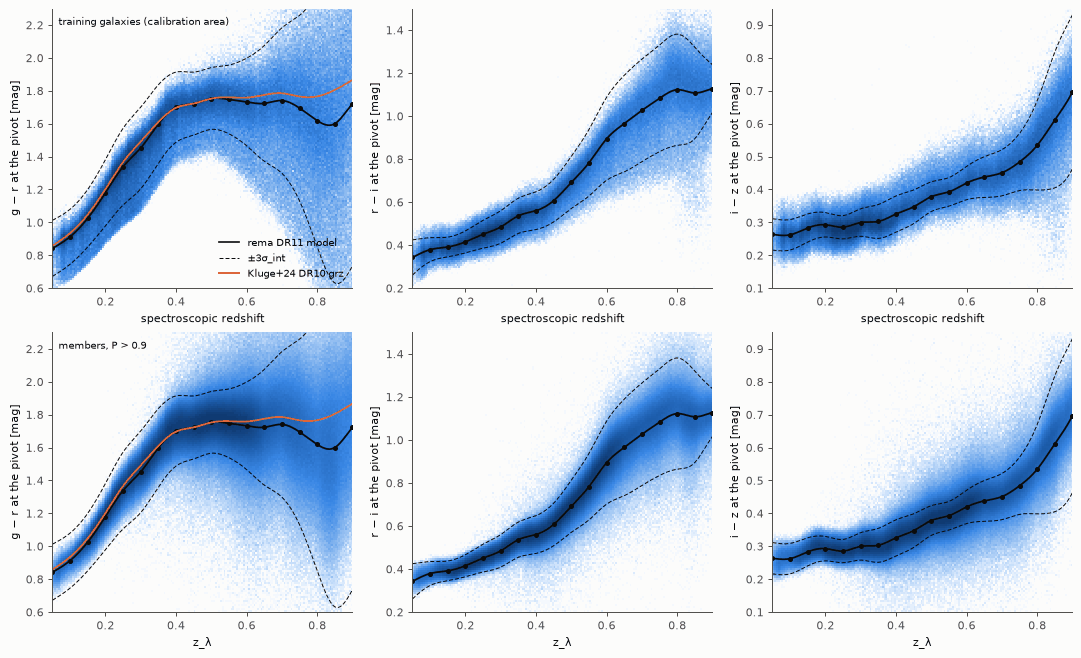

In [15]:
mem = load("members", ["P", "GR", "RI", "IZ", "REFMAG", "Z"])
sel = np.flatnonzero(np.asarray(mem["P"]) > 0.9)
mz = np.asarray(mem["Z"])[sel]
mref = np.asarray(mem["REFMAG"])[sel]
mcol = np.stack([np.asarray(mem[c])[sel] for c in ("GR", "RI", "IZ")], axis=1)
ok = np.all(np.isfinite(mcol), axis=1) & (mz > 0.05) & (mz < 0.9)
mz, mref, mcol = mz[ok], mref[ok], mcol[ok]
mpiv = np.stack([colour_at_pivot(mcol[:, j], mref, mz, j) for j in range(3)], axis=1)
print(f"{mz.size:,} members with P > 0.9 and positive fluxes in g, r, i, z")

spec_file = RUNS[0] / "calib" / "plots" / "rs_specz.fits"
if spec_file.exists():
    d = read_table(spec_file)
    red = (np.asarray(d["CHISQ"]) < 20.0) & np.all(np.isfinite(d["COLOR_PIV"]), axis=1)
    sz, sc = np.asarray(d["Z"])[red], np.asarray(d["COLOR_PIV"])[red]
    print(f"{red.sum():,} training galaxies with chi2 < 20 (of {red.size:,} brighter than m* + 1)")
else:
    sz = sc = None
    print("rs_specz.fits not found: the top row is left out")

from matplotlib.colors import LogNorm  # noqa: E402

YLIM = [(0.6, 2.3), (0.2, 1.5), (0.1, 0.95)]
rows = 2 if sz is not None else 1
fig, axes = plt.subplots(rows, 3, figsize=(12, 3.6 * rows), constrained_layout=True, squeeze=False)
for r in range(rows):
    z_, c_ = (sz, sc) if (r == 0 and sz is not None) else (mz, mpiv)
    for j, ax in enumerate(axes[r]):
        ax.hist2d(z_, c_[:, j], bins=[np.linspace(0.05, 0.9, 171), np.linspace(*YLIM[j], 141)],
                  cmap=RAMP, norm=LogNorm(vmin=1), rasterized=True)
        ax.plot(ZR, MEAN[:, j], color=INK, lw=1.4, label="rema DR11 model")
        for s in (-3, 3):
            ax.plot(ZR, MEAN[:, j] + s * SIG[:, j], color=INK, lw=0.8, ls=(0, (4, 2)),
                    label="±3σ_int" if s > 0 else None)
        ax.plot(np.asarray(RS.z_mean), np.interp(RS.z_mean, ZR, MEAN[:, j]), "o", ms=3, color=INK)
        if KLUGE is not None and j == 0:
            ax.plot(ZR, K_MEAN[:, 0], color=ORANGE, lw=1.4, label="Kluge+24 DR10 grz")
        ax.set_ylim(*YLIM[j])
        ax.set_xlim(0.05, 0.9)
        ax.set_ylabel(f"{COLOURS[j]} at the pivot [mag]")
        ax.set_xlabel("spectroscopic redshift" if (r == 0 and sz is not None) else "z_λ")
    panel_label(axes[r, 0], "training galaxies (calibration area)" if (r == 0 and sz is not None)
                else "members, P > 0.9")
axes[0, 0].legend(loc="lower right")
save(fig, "rs_colour_z")

### Red-sequence parameters (Rykoff et al. 2014 Fig. 5)

Mean colour at the pivot, slope dc/dm and intrinsic scatter σ_int of each colour, and the
pivot magnitude against m*(z). Kluge et al. (2024) fitted g − r and r − z (grz bands): their
g − r is drawn with the rema g − r, their r − z with the rema (r − i) + (i − z).

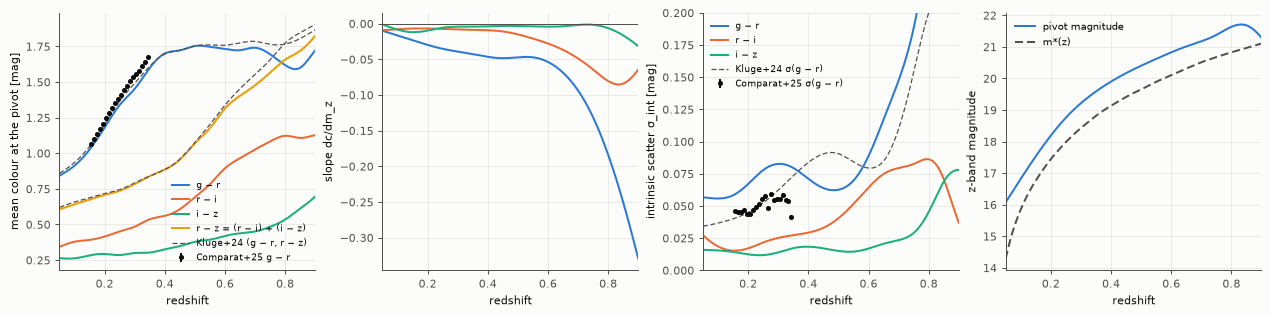

z = 0.2: sigma_int(g-r, r-i, i-z) = 0.067, 0.017, 0.012
z = 0.4: sigma_int(g-r, r-i, i-z) = 0.071, 0.029, 0.018
z = 0.6: sigma_int(g-r, r-i, i-z) = 0.089, 0.064, 0.017
z = 0.8: sigma_int(g-r, r-i, i-z) = 0.256, 0.086, 0.045


In [16]:
from rema.model.profiles import MStar  # noqa: E402

rz = MEAN[:, 1] + MEAN[:, 2]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
ax = axes[0]
for j in range(3):
    ax.plot(ZR, MEAN[:, j], color=SERIES[j], label=f"{COLOURS[j]}")
ax.plot(ZR, rz, color=SERIES[3], label="r − z = (r − i) + (i − z)")
if KLUGE is not None:
    ax.plot(ZR, K_MEAN[:, 0], color=INK2, lw=1.0, ls=(0, (4, 2)), label="Kluge+24 (g − r, r − z)")
    ax.plot(ZR, K_MEAN[:, 1], color=INK2, lw=1.0, ls=(0, (4, 2)))
ax.errorbar(COMPARAT[:, 0], COMPARAT[:, 1], yerr=COMPARAT[:, 2], fmt="o", ms=3, color=INK,
            label="Comparat+25 g − r")
ax.set_ylabel("mean colour at the pivot [mag]")
ax.legend(loc="lower right", fontsize=7)
ax = axes[1]
for j in range(3):
    ax.plot(ZR, SLOPE[:, j], color=SERIES[j], label=COLOURS[j])
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("slope dc/dm_z")
ax = axes[2]
for j in range(3):
    ax.plot(ZR, SIG[:, j], color=SERIES[j], label=COLOURS[j])
if KLUGE is not None:
    ax.plot(ZR, K_SIG[:, 0], color=INK2, lw=1.0, ls=(0, (4, 2)), label="Kluge+24 σ(g − r)")
ax.errorbar(COMPARAT[:, 0], COMPARAT[:, 3], yerr=COMPARAT[:, 4], fmt="o", ms=3, color=INK,
            label="Comparat+25 σ(g − r)")
ax.set_ylim(0, 0.2)
ax.set_ylabel("intrinsic scatter σ_int [mag]")
ax.legend(loc="upper left", fontsize=7)
ax = axes[3]
ms = np.asarray(MStar(CAL.config.model.mstar)(ZR))
ax.plot(ZR, PIVOT, color=BLUE, label="pivot magnitude")
ax.plot(ZR, ms, color=INK2, ls=(0, (4, 2)), label="m*(z)")
ax.set_ylabel("z-band magnitude")
ax.legend(loc="upper left")
for ax in axes:
    ax.set_xlabel("redshift")
    ax.set_xlim(0.05, 0.9)
save(fig, "rs_parameters")

for zz in (0.2, 0.4, 0.6, 0.8):
    i = np.argmin(np.abs(ZR - zz))
    print(f"z = {zz}: sigma_int(g-r, r-i, i-z) = {SIG[i, 0]:.3f}, {SIG[i, 1]:.3f}, {SIG[i, 2]:.3f}")
    record(f"rs_sig_z{zz}", [round(float(s), 4) for s in SIG[i]])

### Composite red sequence (Rykoff et al. 2014 Fig. 3)

Members with P > 0.9 in four thin slices of z_λ, in the colour that straddles the 4000 Å
break at that redshift, against the reference (z-band) magnitude, with the model mean and
±1σ_int.

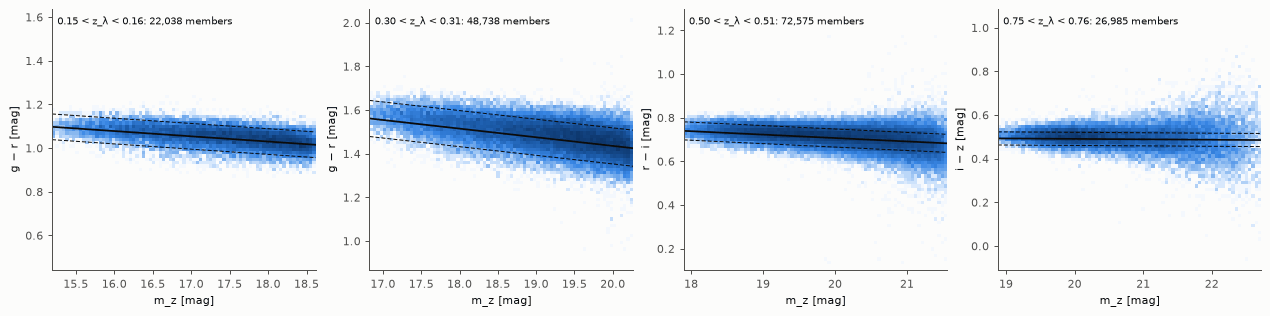

In [17]:
SLICES = [(0.15, 0.16, 0), (0.30, 0.31, 0), (0.50, 0.51, 1), (0.75, 0.76, 2)]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
for ax, (z0, z1, j) in zip(axes, SLICES):
    s = (mz >= z0) & (mz < z1)
    zc = 0.5 * (z0 + z1)
    a = RS.at(np.array([zc]))
    m0, sl, pv = float(np.asarray(a.mean)[0, j]), float(np.asarray(a.slope)[0, j]), float(np.asarray(a.pivot)[0])
    sg = float(np.sqrt(np.asarray(a.cint)[0, j, j]))
    xm = np.linspace(np.percentile(mref[s], 0.5), np.percentile(mref[s], 99.5), 50)
    ylo, yhi = m0 - 0.6, m0 + 0.6
    ax.hist2d(mref[s], mcol[s, j], bins=[np.linspace(xm[0], xm[-1], 80), np.linspace(ylo, yhi, 80)],
              cmap=RAMP, norm=LogNorm(vmin=1), rasterized=True)
    mod = m0 + sl * (xm - pv)
    ax.plot(xm, mod, color=INK, lw=1.4)
    ax.plot(xm, mod - sg, color=INK, lw=0.8, ls=(0, (4, 2)))
    ax.plot(xm, mod + sg, color=INK, lw=0.8, ls=(0, (4, 2)))
    ax.set_xlabel("m_z [mag]")
    ax.set_ylabel(f"{COLOURS[j]} [mag]")
    panel_label(ax, f"{z0:.2f} < z_λ < {z1:.2f}: {s.sum():,} members")
save(fig, "rs_cmd")

## Cluster redshifts

z_λ against spectroscopic redshifts. The spectroscopic redshifts come with the DR11
photo-z sweeps (the compilation of their `Z_SPEC` column: SDSS, BOSS, eBOSS, DESI, GAMA,
...). For a cluster they are either the redshift of the central galaxy (`CG_SPEC_Z`) or the
biweight mean of the members kept by the velocity clipping (`SPEC_Z_BOOT`, at least 3
members). The calibration area (RA 160–180° and 190–210°, Dec −10–10°) trained the
red-sequence model and the z_λ correction with these redshifts, so the statistics are given
for the rest of the sky ("independent") and for the calibration area separately.

145,133 clusters with lambda >= 20, 35,922 with a central spectroscopic redshift (32,168 outside the calibration area)


7,781 of them with >= 2 spectroscopic members within 1000 km/s of the central


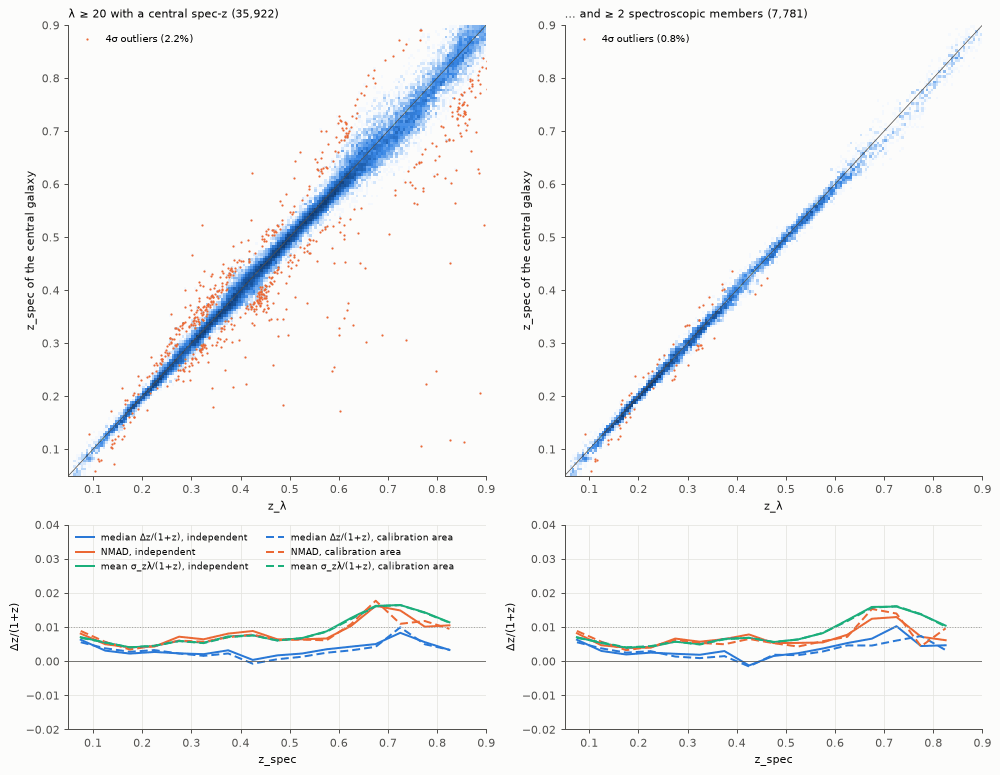

all   : z < 0.6 bias +0.0023, NMAD 0.0067, mean sigma_zl/(1+z) 0.0066; 4 sigma outliers 2.24% (32,168 clusters)
clean : z < 0.6 bias +0.0023, NMAD 0.0053, mean sigma_zl/(1+z) 0.0056; 4 sigma outliers 0.86% (6,661 clusters)
calib : z < 0.6 bias +0.0016, NMAD 0.0065, mean sigma_zl/(1+z) 0.0066; 4 sigma outliers 2.13% (3,754 clusters)


In [18]:
cl = load("clusters")
lam, zl, zle = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"]), np.asarray(cl["Z_LAMBDA_E"])
cgz = np.asarray(cl["CG_SPEC_Z"])
calib = np.asarray(cl["IN_CALIB"])
base = (lam >= 20) & (cgz > 0.03) & (zl > 0.05)
print(f"{(lam >= 20).sum():,} clusters with lambda >= 20, {base.sum():,} with a central spectroscopic "
      f"redshift ({(base & ~calib).sum():,} outside the calibration area)")

# Clusters with >= 2 other members (P >= 0.8) with a spectroscopic redshift within 1000 km/s of
# the central's (Rykoff et al. 2014 Fig. 10).
mem = load("members", ["CL_ROW", "P", "ZSPEC", "CENT_RANK"])
mrow, mp, mzs = np.asarray(mem["CL_ROW"]), np.asarray(mem["P"]), np.asarray(mem["ZSPEC"])
use = (mp >= 0.8) & (mzs > 0) & (np.asarray(mem["CENT_RANK"]) != 0)
use &= base[mrow]
dv = C_KMS * np.abs(mzs[use] - cgz[mrow[use]]) / (1 + cgz[mrow[use]])
n_close = np.bincount(mrow[use][dv < 1000.0], minlength=lam.size)
clean = base & (n_close >= 2)
print(f"{clean.sum():,} of them with >= 2 spectroscopic members within 1000 km/s of the central")

ZEDGES = np.arange(0.05, 0.851, 0.05)


def zstats(sel):
    """Per z_spec bin: bias, NMAD/(1+z), mean sigma_z/(1+z), 4 sigma outlier fraction."""
    dz = (zl[sel] - cgz[sel]) / (1 + cgz[sel])
    b = binned(cgz[sel], dz, ZEDGES, min_n=20)
    b["err"] = binned(cgz[sel], zle[sel] / (1 + cgz[sel]), ZEDGES, min_n=20)["mean"]
    out4 = np.abs(zl[sel] - cgz[sel]) > 4 * zle[sel]
    b["out4"] = binned(cgz[sel], out4.astype(float), ZEDGES, min_n=20)["mean"]
    return b


def zl_panel(ax_top, ax_bot, sel, title):
    from matplotlib.colors import LogNorm

    ax_top.hist2d(zl[sel], cgz[sel], bins=[np.linspace(0.05, 0.9, 171)] * 2, cmap=RAMP, norm=LogNorm(vmin=1),
                  rasterized=True)
    out4 = sel & (np.abs(zl - cgz) > 4 * zle)
    ax_top.plot(zl[out4], cgz[out4], ".", ms=1.5, color=ORANGE, rasterized=True,
                label=f"4σ outliers ({out4.sum() / sel.sum():.1%})")
    ax_top.plot([0, 1], [0, 1], color=INK2, lw=0.6)
    ax_top.set_xlim(0.05, 0.9)
    ax_top.set_ylim(0.05, 0.9)
    ax_top.set_xlabel("z_λ")
    ax_top.set_ylabel("z_spec of the central galaxy")
    ax_top.legend(loc="upper left")
    panel_label(ax_top, "")
    ax_top.set_title(title, loc="left")
    for part, ls, lab in ((~calib, "-", "independent"), (calib, (0, (4, 2)), "calibration area")):
        b = zstats(sel & part)
        ax_bot.plot(b["x"], b["med"], color=BLUE, ls=ls, label=f"median Δz/(1+z), {lab}")
        ax_bot.plot(b["x"], b["nmad"], color=ORANGE, ls=ls, label=f"NMAD, {lab}")
        ax_bot.plot(b["x"], b["err"], color=AQUA, ls=ls, label=f"mean σ_zλ/(1+z), {lab}")
    ax_bot.axhline(0, color=INK2, lw=0.6)
    ax_bot.axhline(LIT["R14_sigz"], color=MUTED, lw=0.8, ls=":")
    ax_bot.set_ylim(-0.02, 0.04)
    ax_bot.set_xlim(0.05, 0.9)
    ax_bot.set_xlabel("z_spec")
    ax_bot.set_ylabel("Δz/(1+z)")


fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
zl_panel(axes[0, 0], axes[1, 0], base, f"λ ≥ 20 with a central spec-z ({base.sum():,})")
zl_panel(axes[0, 1], axes[1, 1], clean, f"… and ≥ 2 spectroscopic members ({clean.sum():,})")
axes[1, 0].legend(ncol=2, fontsize=7, loc="upper left")
save(fig, "zl_vs_zspec")

for name, sel in (("all", base & ~calib), ("clean", clean & ~calib), ("calib", base & calib)):
    low = sel & (cgz < 0.6)
    dz = (zl[low] - cgz[low]) / (1 + cgz[low])
    o4 = np.mean(np.abs(zl[sel] - cgz[sel]) > 4 * zle[sel])
    print(f"{name:6s}: z < 0.6 bias {np.median(dz):+.4f}, NMAD {nmad(dz):.4f}, "
          f"mean sigma_zl/(1+z) {np.mean(zle[low] / (1 + cgz[low])):.4f}; 4 sigma outliers {o4:.2%} "
          f"({sel.sum():,} clusters)")
    record(f"zl_{name}_bias", np.median(dz))
    record(f"zl_{name}_nmad", nmad(dz))
    record(f"zl_{name}_err", np.mean(zle[low] / (1 + cgz[low])))
    record(f"zl_{name}_out4", o4)
    record(f"zl_{name}_n", int(sel.sum()))

### Outlier fractions (Rykoff et al. 2014 Fig. 11)

Fraction of clusters (λ ≥ 20, central spectroscopic redshift) with |z_λ − z_spec| larger
than 3, 4 or 5 σ_zλ, in windows of z_λ ± 0.025, outside the calibration area. A Gaussian
would give 0.27%, 0.006% and 0.00006%. The clean sample (≥ 2 spectroscopic members near
the central) removes most of the outliers: they are mostly miscentred clusters or
projections, as in Rykoff et al. (2014).

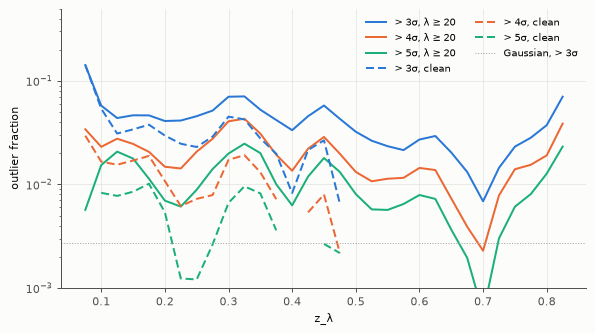

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)
zc = np.arange(0.075, 0.826, 0.025)
for sel, ls, lab in ((base & ~calib, "-", "λ ≥ 20"), (clean & ~calib, (0, (4, 2)), "clean")):
    for k, (n, col) in enumerate(((3, BLUE), (4, ORANGE), (5, AQUA))):
        frac = []
        for z0 in zc:
            w = sel & (np.abs(zl - z0) < 0.025)
            frac.append(np.mean(np.abs(zl[w] - cgz[w]) > n * zle[w]) if w.sum() > 30 else np.nan)
        frac = np.where(np.asarray(frac) > 0, frac, np.nan)          # no outlier: off the log axis
        ax.plot(zc, frac, color=col, ls=ls, label=f"> {n}σ, {lab}")
ax.axhline(0.0027, color=MUTED, lw=0.8, ls=":", label="Gaussian, > 3σ")
ax.set_yscale("log")
ax.set_ylim(1e-3, 0.5)
ax.set_xlabel("z_λ")
ax.set_ylabel("outlier fraction")
ax.legend(ncol=2)
save(fig, "zl_outliers")

### Redshift distribution (Rykoff et al. 2014 Fig. 12)

For the clusters with λ ≥ 20 and a central spectroscopic redshift: the histogram of z_spec,
of z_λ, and the sum of the P(z) of each cluster (with its Poisson ±1σ band). If P(z) is a
fair description of the errors, the sum follows the z_spec histogram.

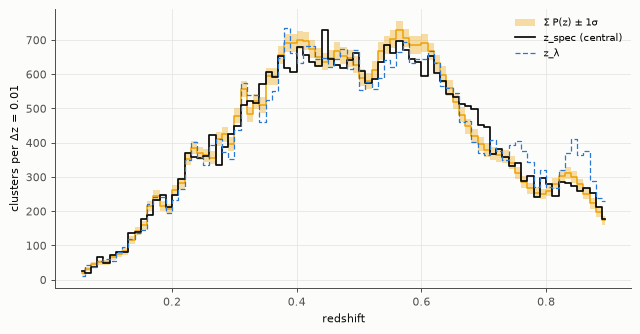

sum P(z) vs N(z_spec): chi2 = 239 for 85 bins


In [20]:
pzb, pz = np.asarray(cl["PZBINS"]), np.asarray(cl["PZ"])
sel = np.flatnonzero(base)
edges = np.arange(0.05, 0.9001, 0.01)
fine = np.arange(0.0, 1.3, 0.001)                 # P(z) is normalised over its whole range
ptot = np.zeros(fine.size)
for i in sel:
    p = np.interp(fine, pzb[i], pz[i], left=0.0, right=0.0)
    s = p.sum()
    if s > 0:
        ptot += p / s
summed = np.histogram(fine, edges, weights=ptot)[0]
fig, ax = plt.subplots(figsize=(7, 3.6), constrained_layout=True)
centres = 0.5 * (edges[1:] + edges[:-1])
ax.fill_between(centres, summed - np.sqrt(summed), summed + np.sqrt(summed), color=YELLOW, alpha=0.35, lw=0,
                step="mid", label="Σ P(z) ± 1σ")
ax.step(centres, summed, where="mid", color=YELLOW, lw=1.2)
ax.step(centres, np.histogram(cgz[sel], edges)[0], where="mid", color=INK, lw=1.4, label="z_spec (central)")
ax.step(centres, np.histogram(zl[sel], edges)[0], where="mid", color=BLUE, lw=1.0, ls=(0, (4, 2)), label="z_λ")
ax.set_xlabel("redshift")
ax.set_ylabel("clusters per Δz = 0.01")
ax.legend()
save(fig, "zl_nz")
h_spec = np.histogram(cgz[sel], edges)[0]
ok = summed > 5
chi2 = np.sum((h_spec[ok] - summed[ok]) ** 2 / summed[ok])
print(f"sum P(z) vs N(z_spec): chi2 = {chi2:.0f} for {ok.sum()} bins")
record("pz_chi2", [round(float(chi2), 1), int(ok.sum())])

### Bias and uncertainty against spectroscopic cluster redshifts (Kluge et al. 2024 Figs. 16-17)

Clusters with a velocity-clipped spectroscopic redshift (`SPEC_Z_BOOT`) from at least 10
members at z < 0.3, 7 at 0.3–0.6 and 3 above, as in Kluge et al. (2024), λ ≥ 10, outside the
calibration area. Left: running median and 16th–84th percentiles of z_λ − z_spec, with the
bias and the empirical uncertainty of Kluge et al. in their four redshift ranges (boxes).
Right: the mean formal error Z_LAMBDA_E against the empirical uncertainty (half the 16–84
range) and the absolute bias.

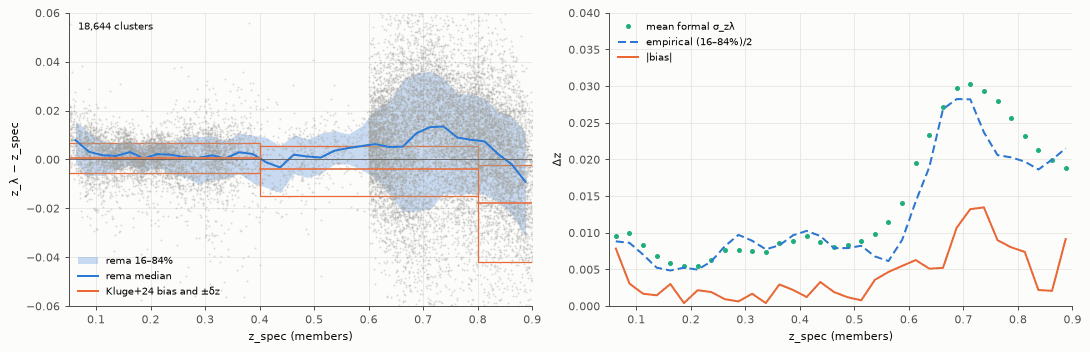

Kluge-like sample: 18,644 clusters; empirical / formal error = 0.93 (median over z)


In [21]:
zsb, nmem = np.asarray(cl["SPEC_Z_BOOT"]), np.asarray(cl["N_MEMBERS"])
need = np.where(zsb < 0.3, 10, np.where(zsb < 0.6, 7, 3))
ksel = (lam >= 10) & np.isfinite(zsb) & (zsb > 0.03) & (nmem >= need) & ~calib & (zl > 0.05)
d = zl[ksel] - zsb[ksel]
edges = np.arange(0.05, 0.901, 0.025)
b = binned(zsb[ksel], d, edges, min_n=15)
e = binned(zsb[ksel], zle[ksel], edges, min_n=15)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
ax = axes[0]
ax.plot(zsb[ksel], d, ".", ms=1, color=MUTED, alpha=0.4, rasterized=True)
ax.fill_between(b["x"], b["p16"], b["p84"], color=BLUE, alpha=0.25, lw=0, label="rema 16–84%")
ax.plot(b["x"], b["med"], color=BLUE, label="rema median")
for (z0, z1), bias, hi, lo in zip(LIT["K24_zbins"], LIT["K24_bias"], LIT["K24_dz_hi"], LIT["K24_dz_lo"]):
    ax.add_patch(plt.Rectangle((z0, bias + lo), z1 - z0, hi - lo, fill=False, ec=ORANGE, lw=1.0))
    ax.plot([z0, z1], [bias, bias], color=ORANGE, lw=1.2)
ax.plot([], [], color=ORANGE, label="Kluge+24 bias and ±δz")
ax.axhline(0, color=INK2, lw=0.6)
ax.set_xlim(0.05, 0.9)
ax.set_ylim(-0.06, 0.06)
ax.set_xlabel("z_spec (members)")
ax.set_ylabel("z_λ − z_spec")
ax.legend(loc="lower left")
panel_label(ax, f"{ksel.sum():,} clusters")
ax = axes[1]
emp = 0.5 * (b["p84"] - b["p16"])
ax.plot(e["x"], e["mean"], "o", ms=3, color=AQUA, label="mean formal σ_zλ")
ax.plot(b["x"], emp, color=BLUE, ls=(0, (4, 2)), label="empirical (16–84%)/2")
ax.plot(b["x"], np.abs(b["med"]), color=ORANGE, label="|bias|")
ax.set_xlim(0.05, 0.9)
ax.set_ylim(0, 0.04)
ax.set_xlabel("z_spec (members)")
ax.set_ylabel("Δz")
ax.legend(loc="upper left")
save(fig, "zl_bias_error")
ratio = np.nanmedian(emp / np.interp(b["x"], e["x"], e["mean"]))
print(f"Kluge-like sample: {ksel.sum():,} clusters; empirical / formal error = {ratio:.2f} (median over z)")
record("zl_k24_n", int(ksel.sum()))
record("zl_k24_emp_over_formal", ratio)
for (z0, z1) in LIT["K24_zbins"]:
    w = (zsb[ksel] >= z0) & (zsb[ksel] < z1)
    if w.sum() > 20:
        record(f"zl_k24_bias_{z0}_{z1}", np.median(d[w]))
        record(f"zl_k24_dz_{z0}_{z1}", [float(np.percentile(d[w], 84) - np.median(d[w])),
                                         float(np.percentile(d[w], 16) - np.median(d[w]))])

### Member zred (Rykoff et al. 2014 Fig. 7)

zred of the members with P > 0.9 against the spectroscopic redshift of their cluster
(central galaxy), outside the calibration area: the zred are those of the catalogue, after
the zred correction ("afterburner") of the calibration. Bottom: mean offset, rms, mean
zred error and the fraction of 4σ outliers per bin.

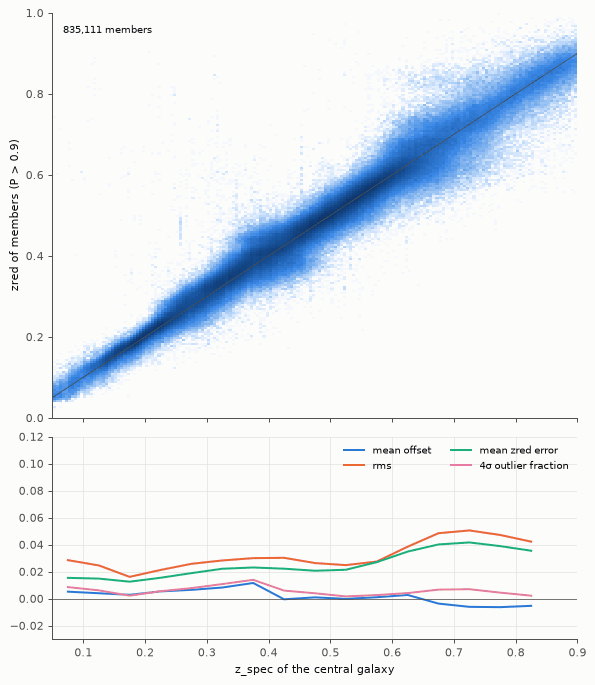

In [22]:
mem = load("members", ["CL_ROW", "P", "ZRED", "ZRED_E", "CENT_RANK"])
mrow = np.asarray(mem["CL_ROW"])
s = (np.asarray(mem["P"]) > 0.9) & (cgz[mrow] > 0.03) & ~calib[mrow]
zr, zre, zc = np.asarray(mem["ZRED"])[s], np.asarray(mem["ZRED_E"])[s], cgz[mrow[s]]
from matplotlib.colors import LogNorm  # noqa: E402

fig, axes = plt.subplots(2, 1, figsize=(6.5, 7.5), constrained_layout=True, sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.hist2d(zc, zr, bins=[np.linspace(0.05, 0.9, 171), np.linspace(0.0, 1.0, 201)], cmap=RAMP,
          norm=LogNorm(vmin=1), rasterized=True)
ax.plot([0, 1], [0, 1], color=INK2, lw=0.6)
ax.set_ylabel("zred of members (P > 0.9)")
panel_label(ax, f"{zr.size:,} members")
ax = axes[1]
dz = zr - zc
b = binned(zc, dz, ZEDGES, min_n=50)
ax.plot(b["x"], b["mean"], color=BLUE, label="mean offset")
ax.plot(b["x"], b["std"], color=ORANGE, label="rms")
ax.plot(b["x"], binned(zc, zre, ZEDGES, min_n=50)["mean"], color=AQUA, label="mean zred error")
ax.plot(b["x"], binned(zc, (np.abs(dz) > 4 * zre).astype(float), ZEDGES, min_n=50)["mean"], color=MAGENTA,
        label="4σ outlier fraction")
ax.axhline(0, color=INK2, lw=0.6)
ax.set_xlim(0.05, 0.9)
ax.set_ylim(-0.03, 0.12)
ax.set_xlabel("z_spec of the central galaxy")
ax.legend(ncol=2)
save(fig, "zred_members")

## Richness

λ is the sum of the membership probabilities of the galaxies brighter than 0.2 L*
(m*(z) + 1.75), corrected for the masked and too shallow part of the cluster aperture:
SCALEVAL = 1/(completeness) multiplies the observed sum, and MASKFRAC is the masked fraction
of the aperture (clusters with MASKFRAC > 0.2 are not kept). z_vlim is the redshift where the
local 10σ z-band depth reaches m* + 1.75: below it the catalogue is volume limited and
SCALEVAL ≈ 1.

In [23]:
cl = load("clusters")
lam, zl = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"])
scale, mfrac, zv = np.asarray(cl["SCALEVAL"]), np.asarray(cl["MASKFRAC"]), np.asarray(cl["ZVLIM"])
mp = load("maps", ["AREA", "ZVLIM"])
area_tot = float(np.sum(mp["AREA"]))
print(f"{lam.size:,} clusters (lambda >= 3) over {area_tot:.0f} deg2; median z_vlim {np.nanmedian(zv):.3f}")

3,481,608 clusters (lambda >= 3) over 18491 deg2; median z_vlim 0.692


### λ against z_λ, SCALEVAL and MASKFRAC (Rykoff et al. 2014 Figs. 19 and 27; Kluge et al. 2024 Fig. B.2)

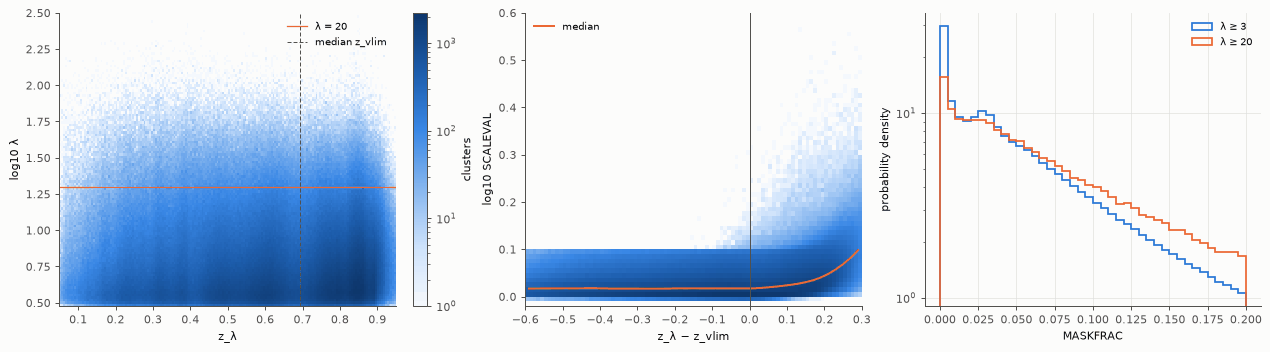

In [24]:
from matplotlib.colors import LogNorm  # noqa: E402

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
ax = axes[0]
h = ax.hist2d(zl, np.log10(lam), bins=[np.linspace(0.05, 0.95, 181), np.linspace(np.log10(3), 2.5, 120)],
              cmap=RAMP, norm=LogNorm(vmin=1), rasterized=True)
ax.axhline(np.log10(20), color=ORANGE, lw=1.0, label="λ = 20")
ax.axvline(np.nanmedian(zv), color=INK2, lw=0.8, ls=(0, (4, 2)), label="median z_vlim")
ax.set_xlabel("z_λ")
ax.set_ylabel("log10 λ")
ax.legend(loc="upper right")
fig.colorbar(h[3], ax=ax, label="clusters")
ax = axes[1]
x = zl - zv
b = binned(x, np.log10(scale), np.arange(-0.6, 0.31, 0.02), min_n=50)
ax.hist2d(x[np.isfinite(x)], np.log10(scale[np.isfinite(x)]), bins=[np.linspace(-0.6, 0.3, 91), np.linspace(-0.02, 0.6, 63)],
          cmap=RAMP, norm=LogNorm(vmin=1), rasterized=True)
ax.plot(b["x"], b["med"], color=ORANGE, label="median")
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel("z_λ − z_vlim")
ax.set_ylabel("log10 SCALEVAL")
ax.legend(loc="upper left")
ax = axes[2]
for lo, col in ((3, BLUE), (20, ORANGE)):
    ax.hist(mfrac[lam >= lo], bins=np.linspace(0, 0.2, 41), histtype="step", color=col, lw=1.4, density=True,
            label=f"λ ≥ {lo}")
ax.set_yscale("log")
ax.set_xlabel("MASKFRAC")
ax.set_ylabel("probability density")
ax.legend()
save(fig, "richness_z")
record("frac_scaleval_gt_1p1_below_zvlim", np.mean(scale[(zl < zv) & (lam >= 20)] > 1.1))
record("median_zvlim", np.nanmedian(zv))

### Richness function (cumulative counts per deg²)

N(> λ) per deg² in four bins of z_λ, in the part of the sky where z_vlim is above the bin
(the volume-limited area, given in the legend). SDSS DR8
(Rykoff et al. 2016, 10,134 deg², λ ≥ 20) and DES Y1 (McClintock et al. 2019, 1,437 deg²,
λ ≥ 20) are drawn for the bins they cover; rema λ is not normalised to their filter sets.

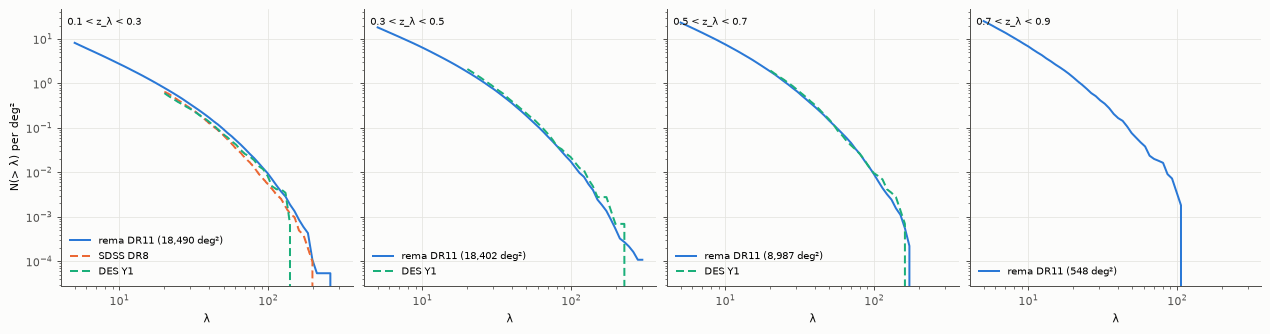

In [25]:
ZB = [(0.1, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9)]
grid = np.logspace(np.log10(5), np.log10(300), 60)
sdss, desy1 = external("sdss_dr8"), external("des_y1")
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), constrained_layout=True, sharey=True)
for ax, (z0, z1) in zip(axes, ZB):
    a = float(np.sum(np.asarray(mp["AREA"])[np.asarray(mp["ZVLIM"]) >= z1]))
    s = (zl >= z0) & (zl < z1) & (zv >= z1)                     # same sky as the area a
    if a > 0 and s.sum():
        n = np.array([(lam[s] >= g).sum() for g in grid]) / a
        ax.plot(grid, n, color=BLUE, label=f"rema DR11 ({a:,.0f} deg²)")
        record(f"n_lam20_z{z0}_{z1}", float((lam[s] >= 20).sum() / a))
    for ref, area, col, lab in ((sdss, LIT["R16_dr8_area"], ORANGE, "SDSS DR8"), (desy1, LIT["DESY1_area"], AQUA, "DES Y1")):
        if ref is None:
            continue
        rs = (ref["Z"] >= z0) & (ref["Z"] < z1)
        if lab == "SDSS DR8" and z1 > 0.35:
            continue                                     # SDSS DR8 is volume limited to z ~ 0.35
        if rs.sum() > 20:
            g = grid[grid >= 20]
            ax.plot(g, np.array([(ref["LAMBDA"][rs] >= x).sum() for x in g]) / area, color=col, ls=(0, (4, 2)),
                    label=lab)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("λ")
    panel_label(ax, f"{z0} < z_λ < {z1}")
    ax.legend(loc="lower left")
axes[0].set_ylabel("N(> λ) per deg²")
save(fig, "richness_function")

### Richness against other redMaPPer catalogues (Kluge et al. 2024 Fig. 11)

One-to-one matches within 1.5′ and |Δz|/(1+z) < 0.02, with MASKFRAC < 0.1 in rema: DES Y1
redMaPPer (deeper DES photometry, griz), SDSS DR8 redMaPPer v6.3 (shallower, ugriz) and the
eROMaPPer λ_norm of Kluge et al. (2024) at the eRASS1 cluster positions (LS DR10, run at
the X-ray positions, normalised to grz). Bottom: the ratio against redshift (running median
and 16–84%); dotted: the ratio expected from Ider Chitham et al. (2020) for SDSS and 0.79 of
Kluge et al. (2024) for DES Y1.

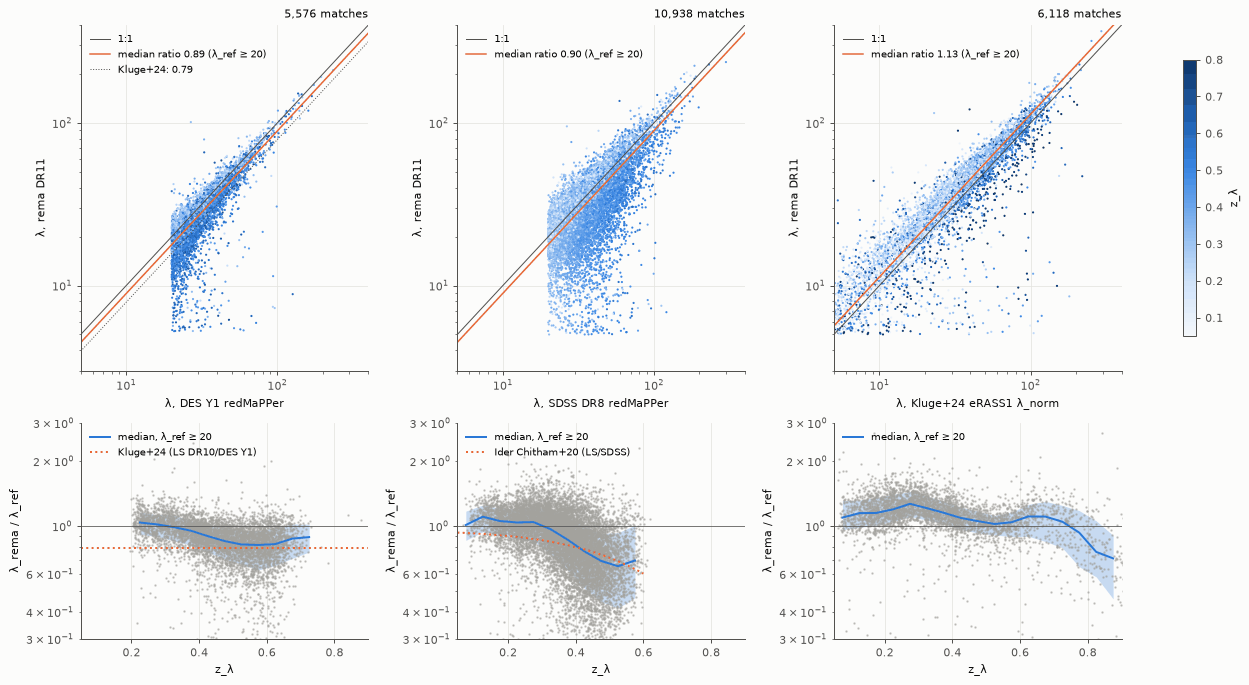

In [26]:
refs = [("des_y1", "DES Y1 redMaPPer", desy1), ("sdss_dr8", "SDSS DR8 redMaPPer", sdss),
        ("erass1", "Kluge+24 eRASS1 λ_norm", external("erass1"))]
refs = [r for r in refs if r[2] is not None]
fig, axes = plt.subplots(2, len(refs), figsize=(4.6 * len(refs), 7.5), constrained_layout=True, squeeze=False,
                         gridspec_kw={"height_ratios": [1.6, 1]})
ok_cl = mfrac < 0.1
for k, (key, lab, ref) in enumerate(refs):
    zr = ref["Z_LAMBDA"] if "Z_LAMBDA" in ref else ref["Z"]
    rra, rdec = (ref["RA_OPT"], ref["DEC_OPT"]) if "RA_OPT" in ref else (ref["RA"], ref["DEC"])
    good = np.isfinite(zr) & np.isfinite(ref["LAMBDA"]) & (ref["LAMBDA"] > 0)
    idx_ref = np.flatnonzero(good)
    sub = np.flatnonzero(ok_cl & (lam >= 5))
    i1, i2 = match_within(np.asarray(cl["RA"])[sub], np.asarray(cl["DEC"])[sub], zl[sub],
                          rra[idx_ref], rdec[idx_ref], zr[idx_ref], 1.5, dz_max=0.02, rank2=ref["LAMBDA"][idx_ref])
    a, r = sub[i1], idx_ref[i2]
    la, lr, zz = lam[a], ref["LAMBDA"][r], zl[a]
    ax = axes[0, k]
    sc = ax.scatter(lr, la, s=3, c=zz, cmap=RAMP, vmin=0.05, vmax=0.8, rasterized=True, lw=0)
    ax.plot([5, 400], [5, 400], color=INK2, lw=0.8, label="1:1")
    big = lr >= 20
    ratio = np.exp(np.median(np.log(la[big] / lr[big]))) if big.sum() > 10 else np.nan
    ax.plot([5, 400], [5 * ratio, 400 * ratio], color=ORANGE, lw=1.2, label=f"median ratio {ratio:.2f} (λ_ref ≥ 20)")
    if key == "des_y1":
        ax.plot([5, 400], [5 * LIT["K24_lam_ratio_desy1"], 400 * LIT["K24_lam_ratio_desy1"]], color=INK2, lw=0.8,
                ls=":", label="Kluge+24: 0.79")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(5, 400)
    ax.set_ylim(3, 400)
    ax.set_xlabel(f"λ, {lab}")
    ax.set_ylabel("λ, rema DR11")
    ax.legend(loc="upper left")
    panel_label(ax, "")
    ax.set_title(f"{a.size:,} matches", loc="right")
    record(f"lam_ratio_{key}", ratio)
    record(f"lam_ratio_{key}_n", int(big.sum()))
    ax = axes[1, k]
    lrat = np.log(la / lr)
    b = binned(zz[big], lrat[big], np.arange(0.05, 0.91, 0.05), min_n=15)
    ax.plot(zz[big], np.exp(lrat[big]), ".", ms=2, color=MUTED, alpha=0.5, rasterized=True)
    ax.fill_between(b["x"], np.exp(b["p16"]), np.exp(b["p84"]), color=BLUE, alpha=0.25, lw=0)
    ax.plot(b["x"], np.exp(b["med"]), color=BLUE, label="median, λ_ref ≥ 20")
    if key == "sdss_dr8":
        zg = np.linspace(0.05, 0.6, 50)
        ax.plot(zg, ider_chitham_lambda(1.0, zg), color=ORANGE, ls=":", label="Ider Chitham+20 (LS/SDSS)")
    if key == "des_y1":
        ax.axhline(LIT["K24_lam_ratio_desy1"], color=ORANGE, ls=":", label="Kluge+24 (LS DR10/DES Y1)")
    ax.axhline(1, color=INK2, lw=0.6)
    ax.set_yscale("log")
    ax.set_ylim(0.3, 3)
    ax.set_xlim(0.05, 0.9)
    ax.set_xlabel("z_λ")
    ax.set_ylabel("λ_rema / λ_ref")
    ax.legend(loc="upper left")
fig.colorbar(sc, ax=axes[0, :], label="z_λ", shrink=0.8)
save(fig, "richness_external")

### Richness against velocity dispersion (Kluge et al. 2024 Fig. 18)

Clusters with at least 15 spectroscopic members after the velocity clipping and an
unflagged dispersion (bootstrap mean). The line is an orthogonal-distance (major-axis) fit of
log λ = a log σ_v + b; dotted: the relation of Kluge et al. (2024) for λ_norm (eRASS1),
multiplied by 1.039, their griz-to-grz normalisation.

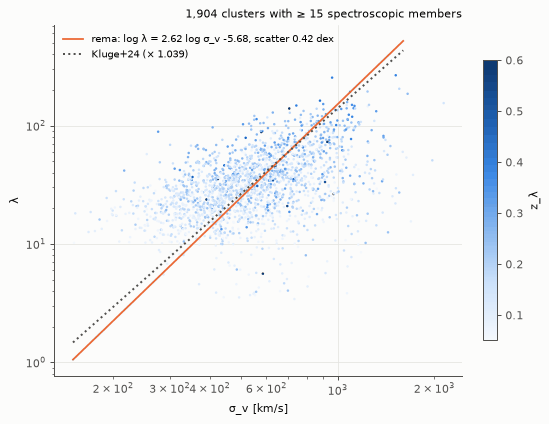

In [27]:
def orthogonal_fit(x, y):
    """Slope and intercept of the orthogonal-distance (major-axis) line through (x, y)."""
    sxx, syy, sxy = np.var(x), np.var(y), np.cov(x, y, bias=True)[0, 1]
    slope = (syy - sxx + np.sqrt((syy - sxx) ** 2 + 4 * sxy**2)) / (2 * sxy)
    return slope, np.mean(y) - slope * np.mean(x)


nm, vd, vflag = np.asarray(cl["N_MEMBERS"]), np.asarray(cl["VDISP_BOOT"]), np.asarray(cl["VDISP_FLAG"])
s = (nm >= 15) & np.isfinite(vd) & (vd > 50) & ~vflag.astype(bool)
x, y = np.log10(vd[s]), np.log10(lam[s])
a_, b_ = orthogonal_fit(x, y)
resid = y - (a_ * x + b_)
fig, ax = plt.subplots(figsize=(6, 4.6), constrained_layout=True)
sc = ax.scatter(vd[s], lam[s], s=4, c=zl[s], cmap=RAMP, vmin=0.05, vmax=0.6, lw=0, rasterized=True)
fig.colorbar(sc, ax=ax, label="z_λ", shrink=0.8)
xs = np.linspace(150, 1600, 50)
ax.plot(xs, 10 ** (a_ * np.log10(xs) + b_), color=ORANGE, lw=1.4,
        label=f"rema: log λ = {a_:.2f} log σ_v {b_:+.2f}, scatter {np.std(resid):.2f} dex")
ka, kb = LIT["K24_lam_sig"]
ax.plot(xs, LIT["K24_snorm_griz"] * 10 ** (ka * np.log10(xs) + kb), color=INK2, ls=":", label="Kluge+24 (× 1.039)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("σ_v [km/s]")
ax.set_ylabel("λ")
ax.legend(loc="upper left")
panel_label(ax, "")
ax.set_title(f"{s.sum():,} clusters with ≥ 15 spectroscopic members", loc="right")
save(fig, "richness_vdisp")
record("lam_sigma_fit", [round(float(a_), 3), round(float(b_), 3), round(float(np.std(resid)), 3), int(s.sum())])

## Depth, volume limit and abundance

The maps come from the DR11 randoms (one file, 2500 per deg²) cut like the run: mask bits,
at least one exposure in g, r, i and z, E(B−V) < 0.2, |b| ≥ 15° and the own boxes of the
regions that finished.

In [28]:
mp = load("maps")
cl = load("clusters")
M = meta()
NSIDE = M["nside"]
pix = np.asarray(mp["PIX"])
area = np.asarray(mp["AREA"])
zvmap = np.asarray(mp["ZVLIM"])
lam, zl, zv = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"]), np.asarray(cl["ZVLIM"])
print(f"run area {area.sum():,.0f} deg2 in {pix.size:,} pixels of NSIDE {NSIDE}: "
      + ", ".join(f"{k} {v:,.0f} deg2" for k, v in M["area"].items()))
record("area_total", float(area.sum()))

run area 18,491 deg2 in 392,095 pixels of NSIDE 256: rema_dr11_v0.2.0_ra0-240 13,068 deg2, rema_dr11_v0.2.0_ra240-360 5,423 deg2


### 10σ depth maps (Rykoff et al. 2016 Fig. 1; Kluge et al. 2024 Figs. 2 and B.1)

Mean 10σ galaxy (`GALDEPTH`) depth per pixel, corrected for Galactic extinction, in the four
bands of the run.

g: median 10 sigma depth 23.64 (2-98%: 22.83-24.38)


r: median 10 sigma depth 23.16 (2-98%: 22.51-24.12)


i: median 10 sigma depth 22.78 (2-98%: 21.80-23.51)


z: median 10 sigma depth 22.24 (2-98%: 21.65-22.87)


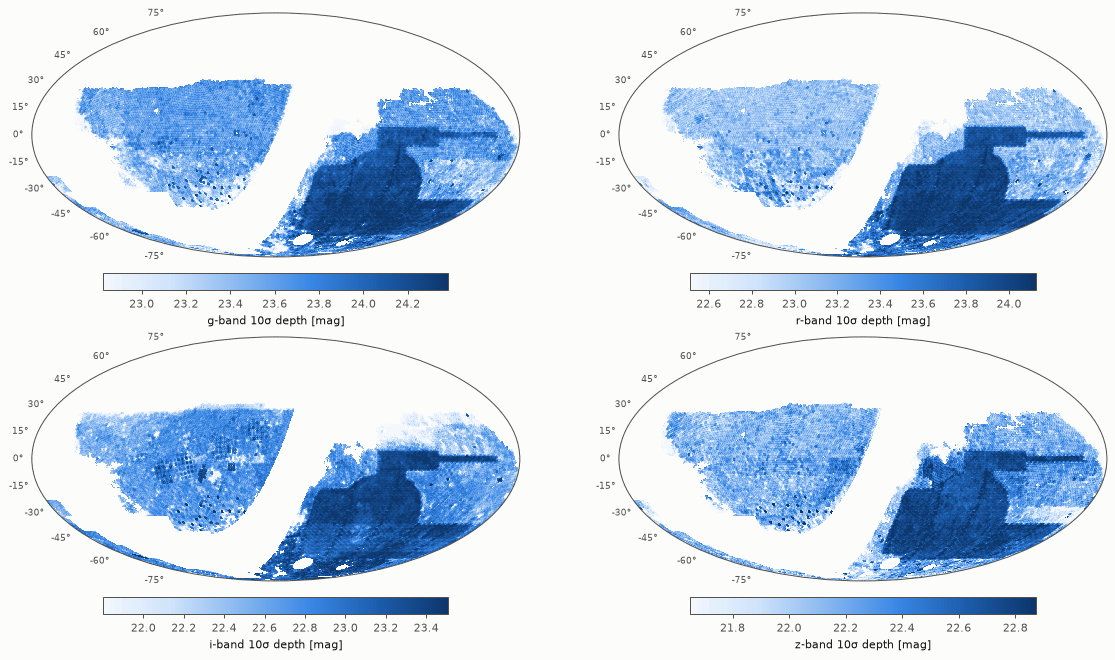

In [29]:
fig = plt.figure(figsize=(13, 7.2), constrained_layout=True)
for k, b in enumerate(["G", "R", "I", "Z"]):
    v = np.asarray(mp[f"DEPTH_{b}10"])
    lo, hi = np.nanpercentile(v, [2, 98])
    ax = sky_axes(fig, 221 + k)
    im = sky_image(ax, NSIDE, pix, v, vmin=lo, vmax=hi)
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.6, pad=0.04, label=f"{b.lower()}-band 10σ depth [mag]")
    print(f"{b.lower()}: median 10 sigma depth {np.median(v):.2f} (2-98%: {lo:.2f}-{hi:.2f})")
    record(f"depth_{b.lower()}10", float(np.median(v)))
save(fig, "depth_maps")

### z_vlim (Kluge et al. 2024 Figs. 3 and B.3)

Left: the z_vlim map. Middle: m*(z) + 1.75 in the z band, which turns the 10σ depth into
z_vlim, and the area per z_vlim. Right: the z_vlim of this map at the positions of the eRASS1
clusters against the `ZVLIM_02` of Kluge et al. (2024), computed from the LS DR10 depth.

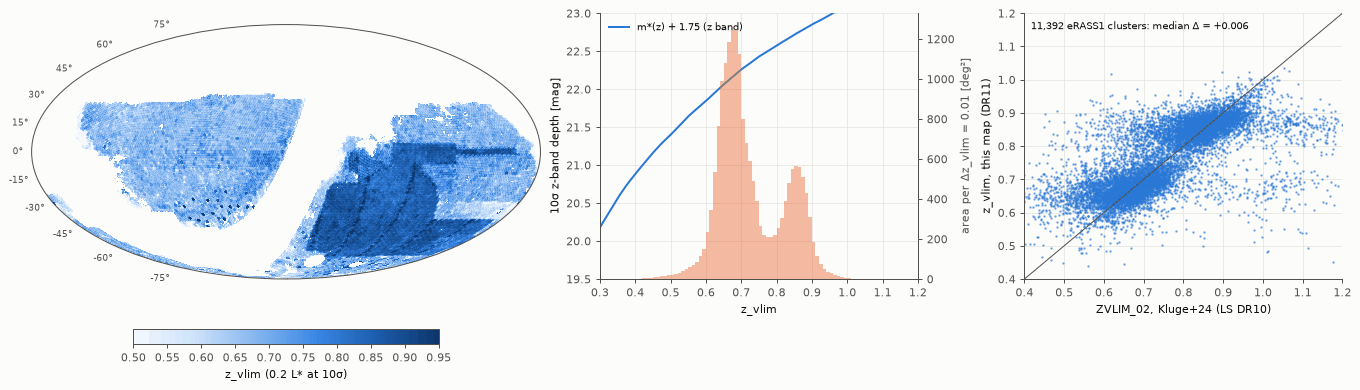

In [30]:
from rema.calibration import Calibration  # noqa: E402
from rema.model.profiles import MStar, maxmag_from_mstar  # noqa: E402

cfg = Calibration.read(CALIB).config
ms = MStar(cfg.model.mstar)
fig = plt.figure(figsize=(15, 4.2), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1.6, 1, 1])
ax = sky_axes(fig, gs[0])
im = sky_image(ax, NSIDE, pix, zvmap, vmin=0.5, vmax=0.95)
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.6, pad=0.04, label="z_vlim (0.2 L* at 10σ)")
ax = fig.add_subplot(gs[1])
zg = np.asarray(ms.z)
mlim = np.asarray(maxmag_from_mstar(np.asarray(ms.m), cfg.model.lval_reference))
ax.plot(zg, mlim, color=BLUE, label="m*(z) + 1.75 (z band)")
ax.set_xlim(0.3, 1.2)
ax.set_ylim(19.5, 23.0)
ax.set_xlabel("z_vlim")
ax.set_ylabel("10σ z-band depth [mag]")
ax2 = ax.twinx()
ax2.hist(zvmap, bins=np.arange(0.3, 1.2, 0.01), weights=area, color=ORANGE, alpha=0.45)
ax2.set_ylabel("area per Δz_vlim = 0.01 [deg²]", color=INK2)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.legend(loc="upper left")
ax = fig.add_subplot(gs[2])
er = external("erass1")
if er is not None:
    i = hp.ang2pix(NSIDE, er["RA"], er["DEC"], lonlat=True, nest=True)
    j = np.searchsorted(pix, i).clip(0, pix.size - 1)
    found = (pix[j] == i) & np.isfinite(er["ZVLIM_02"]) & (er["ZVLIM_02"] > 0)
    ax.plot(er["ZVLIM_02"][found], zvmap[j[found]], ".", ms=2, color=BLUE, alpha=0.5, rasterized=True)
    ax.plot([0.3, 1.3], [0.3, 1.3], color=INK2, lw=0.8)
    dzv = zvmap[j[found]] - er["ZVLIM_02"][found]
    panel_label(ax, f"{found.sum():,} eRASS1 clusters: median Δ = {np.median(dzv):+.3f}")
    record("zvlim_minus_k24", float(np.median(dzv)))
    ax.set_xlim(0.4, 1.2)
    ax.set_ylim(0.4, 1.2)
ax.set_xlabel("ZVLIM_02, Kluge+24 (LS DR10)")
ax.set_ylabel("z_vlim, this map (DR11)")
save(fig, "zvlim")

### Effective area against z_vlim (Kluge et al. 2024 Fig. 3)

Area of the run where z_vlim exceeds a given redshift, in total and in the half of the sky
covered by eRASS1 (Galactic longitude > 180°).

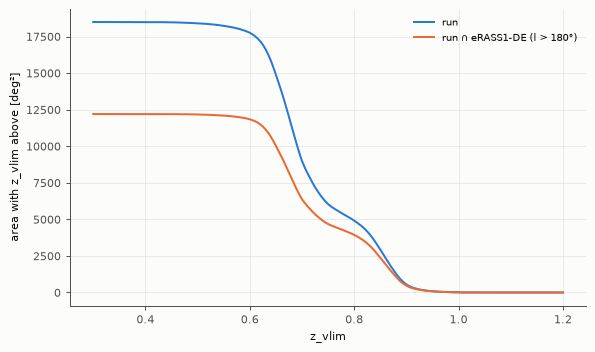

In [31]:
lon = hp.pix2ang(NSIDE, pix, nest=True, lonlat=True)
gl = SkyCoord(lon[0] * u.deg, lon[1] * u.deg).galactic.l.deg
zgrid = np.linspace(0.3, 1.2, 181)
fig, ax = plt.subplots(figsize=(6.5, 3.8), constrained_layout=True)
for sel, col, lab in ((np.ones(pix.size, bool), BLUE, "run"), (gl > 180, ORANGE, "run ∩ eRASS1-DE (l > 180°)")):
    ax.plot(zgrid, [area[sel & (zvmap >= z)].sum() for z in zgrid], color=col, label=lab)
ax.set_xlabel("z_vlim")
ax.set_ylabel("area with z_vlim above [deg²]")
ax.legend()
save(fig, "area_zvlim")
for z in (0.6, 0.7, 0.8):
    record(f"area_zvlim_{z}", float(area[zvmap >= z].sum()))

### Cluster density against redshift (Rykoff et al. 2014 Fig. 18; Rykoff et al. 2016 Fig. 6; Kluge et al. 2024 Fig. 12)

Clusters in the sky where z_vlim is above the upper edge of their z_λ bin, divided by the area
of that sky. Left: per deg² and per Δz = 0.05. Right: comoving density, with the abundance of halos
above M500c = 0.7, 1.0 and 1.3 × 10¹⁴ M☉ (Tinker et al. 2008 mass function, colossus,
Ωm = 0.3, h = 0.7, σ8 = 0.8), the levels of SDSS DR8 (Rykoff et al. 2014, z < 0.35) and the
densities of SDSS DR8 v6.3 and DES Y1 redMaPPer (λ ≥ 20) with their published areas.

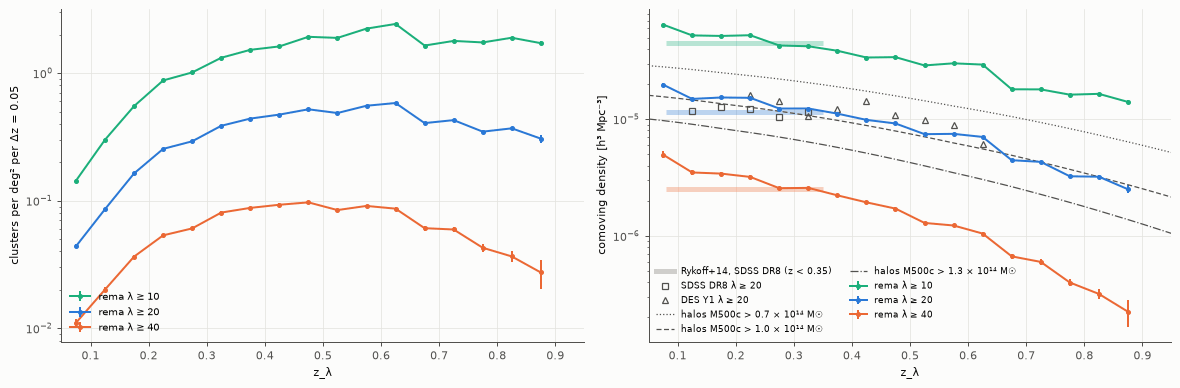

In [32]:
try:
    from colossus.cosmology import cosmology
    from colossus.lss import mass_function

    cosmology.setCosmology("rema", {"flat": True, "H0": 70.0, "Om0": 0.3, "Ob0": 0.045, "sigma8": 0.8, "ns": 0.96})
except ImportError:                                  # optional: the halo curves are left out
    mass_function = None
    print("colossus is not installed: the halo mass function curves are left out")
DZ = 0.05
zedges = np.arange(0.05, 0.951, DZ)
zc = 0.5 * (zedges[1:] + zedges[:-1])
sr_per_deg2 = (np.pi / 180.0) ** 2
dvol = np.array([COSMO.comoving_volume(z1).value - COSMO.comoving_volume(z0).value
                 for z0, z1 in zip(zedges[:-1], zedges[1:])]) / (4 * np.pi) * sr_per_deg2 * H ** 3  # (Mpc/h)^3 per deg2
a_z = np.array([area[zvmap >= z1].sum() for z1 in zedges[1:]])


def densities(sel):
    """Clusters per deg2 and per (h^-1 Mpc)^3 in each z bin, in the sky where z_vlim is above the bin."""
    k = np.digitize(zl, zedges) - 1
    inside = (k >= 0) & (k < zc.size)
    deep = inside & (zv >= zedges[np.clip(k + 1, 0, zedges.size - 1)])
    n = np.bincount(k[sel & deep], minlength=zc.size)[:zc.size]
    with np.errstate(divide="ignore", invalid="ignore"):
        na = np.where(a_z > 100, n / a_z, np.nan)
    return na, na / dvol, np.where(a_z > 100, np.sqrt(n) / a_z, np.nan)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
for lmin, col in ((10, AQUA), (20, BLUE), (40, ORANGE)):
    na, nv, ena = densities(lam >= lmin)
    axes[0].errorbar(zc, na, yerr=ena, color=col, marker="o", ms=3, label=f"rema λ ≥ {lmin}")
    axes[1].errorbar(zc, nv, yerr=ena / dvol, color=col, marker="o", ms=3, label=f"rema λ ≥ {lmin}")
    axes[1].hlines(LIT["R14_nV"][lmin], 0.08, 0.35, color=col, lw=4, alpha=0.3)
    sel_mid = (zc > 0.15) & (zc < 0.55)
    record(f"nV_lam{lmin}", float(np.nanmedian(nv[sel_mid])))
    record(f"nA_lam{lmin}", float(np.sum((lam >= lmin) & (zl < zv) & (zl > 0.05)) / area.sum()))
axes[1].plot([], [], color=MUTED, lw=4, alpha=0.5, label="Rykoff+14, SDSS DR8 (z < 0.35)")
for ref_name, area_ref, z0, z1, mk in (("sdss_dr8", LIT["R16_dr8_area"], 0.08, 0.35, "s"),
                                      ("des_y1", LIT["DESY1_area"], 0.2, 0.65, "^")):
    ref = external(ref_name)
    if ref is None:
        continue
    s = (ref["LAMBDA"] >= 20) & (ref["Z"] >= z0) & (ref["Z"] < z1)
    n = np.histogram(ref["Z"][s], zedges)[0].astype(float)
    inside = (zc > z0) & (zc < z1)
    axes[1].plot(zc[inside], (n / area_ref / dvol)[inside], mk, ms=5, mfc="none", color=INK2,
                 label=f"{ref_name.replace('_', ' ').upper()} λ ≥ 20")
zf = np.linspace(0.05, 0.95, 37)
for m14, ls in ((0.7, ":"), (1.0, (0, (4, 2))), (1.3, "-.")) if mass_function is not None else ():
    lnm = np.linspace(np.log(m14 * 1e14 * H), np.log(3e15), 200)       # Msun/h
    nh = [np.trapezoid(mass_function.massFunction(np.exp(lnm), z, mdef="500c", model="tinker08",
                                                  q_out="dndlnM"), lnm) for z in zf]
    axes[1].plot(zf, nh, color=INK2, lw=1.0, ls=ls, label=f"halos M500c > {m14} × 10¹⁴ M☉")
axes[0].set_ylabel("clusters per deg² per Δz = 0.05")
axes[1].set_ylabel("comoving density [h³ Mpc⁻³]")
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("z_λ")
    ax.set_xlim(0.05, 0.95)
axes[1].legend(fontsize=7, ncol=2, loc="lower left")
axes[0].legend(loc="lower left")
save(fig, "density_z")

### Density against depth (Kluge et al. 2024 Fig. 13)

Clusters per deg² in the plane of z_vlim (the local depth) and λ, in five bins of z_λ,
divided at each λ by the density in the volume-limited sky (z_vlim above the bin). The
vertical line marks z_vlim = z_λ: to its right the density should not depend on z_vlim (ratio
1); to its left λ is extrapolated with SCALEVAL, and clusters scatter across the λ threshold.

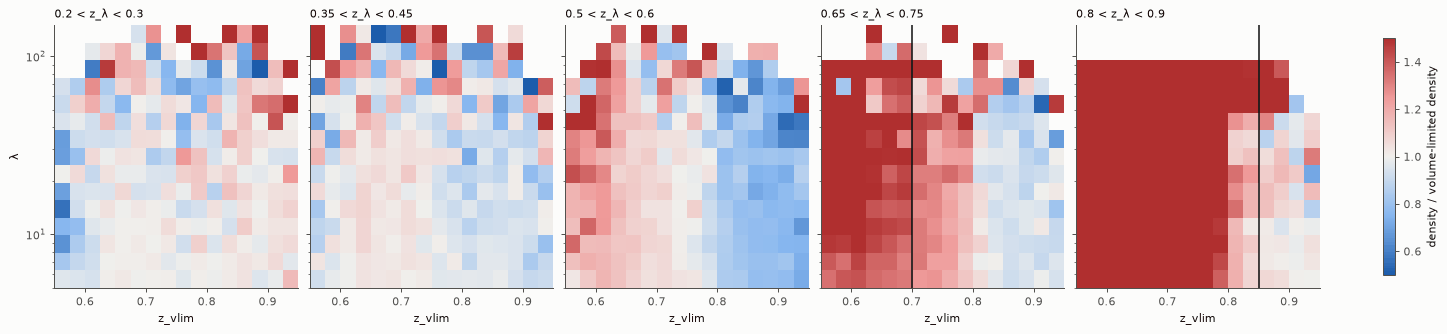

In [33]:
ZB = [(0.2, 0.3), (0.35, 0.45), (0.5, 0.6), (0.65, 0.75), (0.8, 0.9)]
zvb = np.arange(0.55, 0.951, 0.025)
lb = np.logspace(np.log10(5), np.log10(150), 16)
a_zv = np.histogram(zvmap, zvb, weights=area)[0]
fig, axes = plt.subplots(1, len(ZB), figsize=(16, 3.6), constrained_layout=True, sharey=True)
for ax, (z0, z1) in zip(axes, ZB):
    s = (zl >= z0) & (zl < z1)
    h = np.histogram2d(zv[s], lam[s], [zvb, lb])[0]
    vl = zvb[:-1] >= z1                                           # volume-limited columns
    ref = h[vl].sum(axis=0) / a_zv[vl].sum() if vl.any() else np.full(lb.size - 1, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where((a_zv[:, None] > 50) & (h >= 3), h / a_zv[:, None] / ref[None, :], np.nan)
    im = ax.pcolormesh(zvb, lb, ratio.T, cmap=DIVERGE, vmin=0.5, vmax=1.5, rasterized=True)
    ax.axvline(0.5 * (z0 + z1), color=INK, lw=1.2)
    ax.set_xlim(zvb[0], zvb[-1])
    ax.set_yscale("log")
    ax.set_xlabel("z_vlim")
    ax.set_title(f"{z0} < z_λ < {z1}", loc="left")
axes[0].set_ylabel("λ")
fig.colorbar(im, ax=axes, label="density / volume-limited density", shrink=0.9)
save(fig, "density_depth")

### Density-contrast maps (Rykoff et al. 2014 Fig. 17; Rykoff et al. 2016 Figs. 2-3)

δ = n/⟨n⟩ − 1 of clusters with λ ≥ 5 (as in Rykoff et al. 2014) in three bins of z_λ, on
NSIDE 32 pixels (3.4 deg²) with at least half of their area in the run and z_vlim above the
bin. The titles compare the rms of δ with the Poisson expectation.

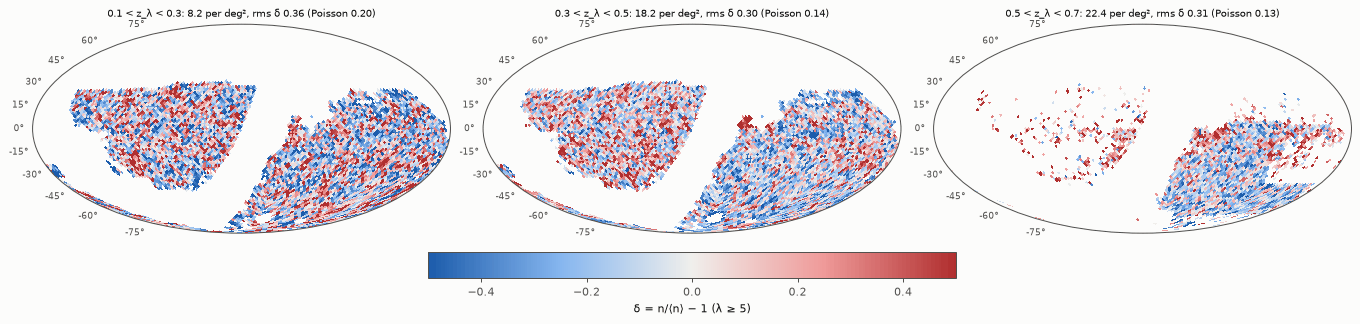

In [34]:
NS_LO = 32
down = (NSIDE // NS_LO) ** 2
lo_pix = pix // down
ZB = [(0.1, 0.3), (0.3, 0.5), (0.5, 0.7)]
fig = plt.figure(figsize=(15, 3.6), constrained_layout=True)
cl_lo = np.asarray(cl["PIX"]) // down
full_area = hp.nside2pixarea(NS_LO, degrees=True)
for k, (z0, z1) in enumerate(ZB):
    deep = zvmap >= z1
    a = np.bincount(lo_pix[deep], weights=area[deep], minlength=hp.nside2npix(NS_LO))
    s = (lam >= 5) & (zl >= z0) & (zl < z1) & (zv >= z1)
    n = np.bincount(cl_lo[s], minlength=hp.nside2npix(NS_LO)).astype(float)
    good = a > 0.5 * full_area
    mean = n[good].sum() / a[good].sum()
    delta = n[good] / a[good] / mean - 1
    poisson = np.sqrt(np.mean(1 / (mean * a[good])))
    ax = sky_axes(fig, 131 + k)
    im = sky_image(ax, NS_LO, np.flatnonzero(good), delta, cmap=DIVERGE, vmin=-0.5, vmax=0.5)
    ax.set_title(f"{z0} < z_λ < {z1}: {mean:.1f} per deg², rms δ {np.std(delta):.2f} (Poisson {poisson:.2f})",
                 fontsize=8)
    record(f"density_contrast_rms_z{z0}_{z1}", [float(np.std(delta)), float(poisson)])
fig.colorbar(im, ax=fig.axes, orientation="horizontal", shrink=0.4, label="δ = n/⟨n⟩ − 1 (λ ≥ 5)")
save(fig, "density_maps")

### Density against observing conditions (Baxter et al. 2016 Fig. 2)

Clusters with λ ≥ 20 and 0.1 < z_λ < 0.5 in pixels where z_vlim > 0.5 (so depth alone should
not change their number), in ten quantiles of each pixel property, normalised by the mean
density; the error bars are Poisson. The last panel is the density against the distance to
the edge of the region (own box) that found the cluster, from the QA file of the merge: the
regions are run separately and their clusters are merged by own box.

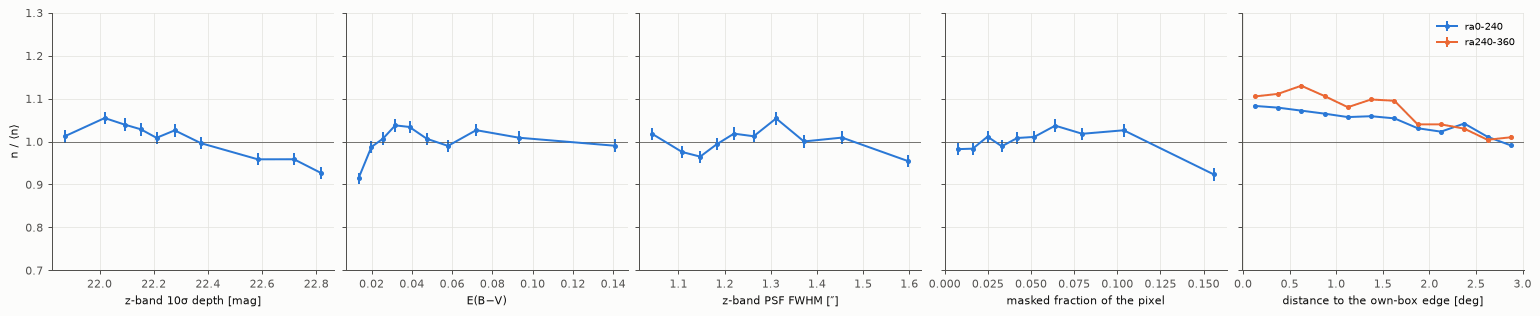

In [35]:
props = [("DEPTH_Z10", "z-band 10σ depth [mag]"), ("EBV", "E(B−V)"), ("PSFSIZE_Z", "z-band PSF FWHM [″]"),
         ("MASKED_FRAC", "masked fraction of the pixel")]
deep = zvmap > 0.5
s = (lam >= 20) & (zl > 0.1) & (zl < 0.5)
cpix = np.asarray(cl["PIX"])
j = np.searchsorted(pix, cpix[s]).clip(0, pix.size - 1)
ok = (pix[j] == cpix[s]) & deep[j]
ncl = np.bincount(j[ok], minlength=pix.size).astype(float)
mean = ncl[deep].sum() / area[deep].sum()
fig, axes = plt.subplots(1, len(props) + 1, figsize=(17, 3.4), constrained_layout=True, sharey=True)
for ax, (name, label) in zip(axes, props):
    v = np.asarray(mp[name])[deep]
    q = np.unique(np.nanpercentile(v, np.linspace(0, 100, 11)))
    k = np.digitize(v, q[1:-1])
    nb = np.bincount(k, weights=ncl[deep], minlength=q.size - 1)
    ab = np.bincount(k, weights=area[deep], minlength=q.size - 1)
    xb = np.array([np.median(v[k == i]) for i in range(q.size - 1)])
    ax.errorbar(xb, nb / ab / mean, yerr=np.sqrt(nb) / ab / mean, color=BLUE, marker="o", ms=3)
    ax.axhline(1, color=INK2, lw=0.6)
    ax.set_xlabel(label)
axes[0].set_ylabel("n / ⟨n⟩")
axes[0].set_ylim(0.7, 1.3)
ax = axes[-1]
for k, run in enumerate(RUNS):
    f = run / "clusters_dr11_qa.json"
    if f.exists():
        ep = json.loads(f.read_text())["edge_profile"]
        x = np.asarray(ep["d_lo"]) + 0.125
        ax.errorbar(x, ep["ratio"], yerr=np.asarray(ep["ratio"]) / np.sqrt(ep["n"]), color=SERIES[k], marker="o",
                    ms=3, label=run.name.replace("rema_dr11_v0.2.0_", ""))
ax.axhline(1, color=INK2, lw=0.6)
ax.set_xlabel("distance to the own-box edge [deg]")
ax.legend()
save(fig, "density_systematics")

## Centring

rema keeps redMaPPer's centring: up to five candidate central galaxies per cluster, each with
a probability P_CEN from the wcen likelihood (luminosity, zred and local density). The
catalogue position is the most likely central.

In [36]:
cl = load("clusters")
lam, zl = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"])
pcen = np.asarray(cl["P_CEN"])
p0 = pcen[:, 0]
rlam = np.asarray(cl["R_LAMBDA"])                    # h^-1 Mpc
ra, dec = np.asarray(cl["RA"]), np.asarray(cl["DEC"])

### Centring probabilities (Rykoff et al. 2016 Sect. 8)

Distribution of the probability of the most likely central, its mean against λ and z_λ, and
the fraction of clusters with P_cen > 0.9.
Rykoff et al. (2016) predicted ⟨P_cen⟩ = 0.82 for DES SV (λ ≥ 20) and measured a well-centred
fraction ρ0 = 0.78 ± 0.11 from X-ray and SZ centres.

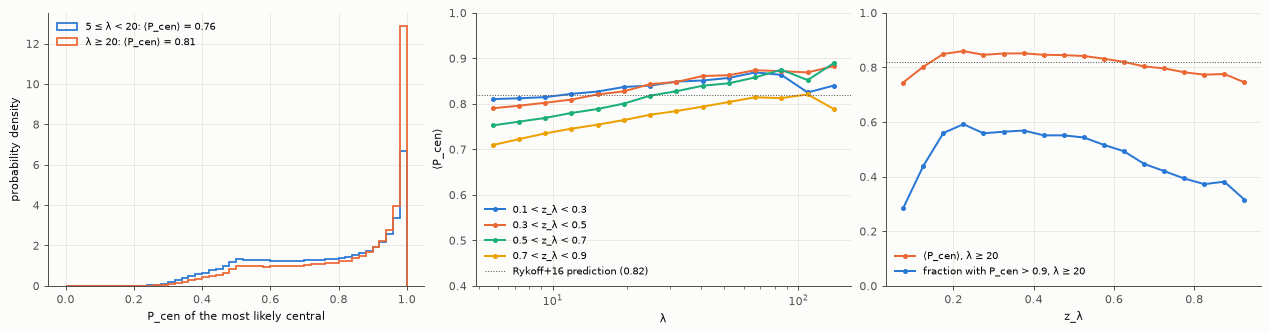

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
ax = axes[0]
for (l0, l1), col in (((5, 20), BLUE), ((20, 1e4), ORANGE)):
    s = (lam >= l0) & (lam < l1)
    lab = f"λ ≥ {l0}" if l1 > 1e3 else f"{l0} ≤ λ < {l1}"
    ax.hist(p0[s], bins=np.linspace(0, 1, 51), histtype="step", density=True, color=col, lw=1.4,
            label=f"{lab}: ⟨P_cen⟩ = {p0[s].mean():.2f}")
ax.set_xlabel("P_cen of the most likely central")
ax.set_ylabel("probability density")
ax.legend(loc="upper left")
ax = axes[1]
lb = np.logspace(np.log10(5), np.log10(200), 16)
for k, (z0, z1) in enumerate(((0.1, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9))):
    s = (zl >= z0) & (zl < z1)
    b = binned(lam[s], p0[s], lb, min_n=30)
    ax.plot(b["x"], b["mean"], color=SERIES[k], marker="o", ms=3, label=f"{z0} < z_λ < {z1}")
ax.axhline(LIT["R16_pcen"], color=INK2, ls=":", lw=0.8, label="Rykoff+16 prediction (0.82)")
ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("⟨P_cen⟩")
ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower left")
ax = axes[2]
s = lam >= 20
b = binned(zl[s], p0[s], np.arange(0.05, 0.951, 0.05), min_n=30)
ax.plot(b["x"], b["mean"], color=ORANGE, marker="o", ms=3, label="⟨P_cen⟩, λ ≥ 20")
b2 = binned(zl[s], (p0[s] > 0.9).astype(float), np.arange(0.05, 0.951, 0.05), min_n=30)
ax.plot(b2["x"], b2["mean"], color=BLUE, marker="o", ms=3, label="fraction with P_cen > 0.9, λ ≥ 20")
ax.axhline(LIT["R16_pcen"], color=INK2, ls=":", lw=0.8)
ax.set_xlabel("z_λ")
ax.set_ylim(0.0, 1.0)
ax.legend(loc="lower left")
save(fig, "centering_pcen")
record("pcen_mean_lam20", float(p0[lam >= 20].mean()))

### Offsets from X-ray and SZ centres (Rykoff et al. 2016 Figs. 11-12; Zhang et al. 2019 Fig. 3)

Each external cluster (redshift > 0.05) is paired with the richest rema cluster (λ ≥ 20)
within 10′ and |z_λ − z|/(1+z) < 0.05; the offset is in units of R_λ at z_λ. The offsets
are fitted with the two-component model of Rykoff et al. (2016): a fraction ρ0 of well
centred clusters, whose offsets follow a Rayleigh distribution of width σ0 (the positional
errors), and miscentred ones, Rayleigh of width σ1 (in R_λ). The external centres are the
eRASS1 X-ray positions (Bulbul et al. 2024), ACT DR6 SZ positions (beam 1.4′) and SPT-SZ
2500d positions (Bocquet et al. 2019).

eRASS1 X-ray: 6030 pairs, rho0 = 0.63, sigma0 = 0.049, sigma1 = 0.39; <P_cen> of the paired clusters 0.86
ACT DR6 SZ: 6714 pairs, rho0 = 0.79, sigma0 = 0.095, sigma1 = 0.37; <P_cen> of the paired clusters 0.87


SPT-SZ 2500d: 405 pairs, rho0 = 0.83, sigma0 = 0.099, sigma1 = 0.37; <P_cen> of the paired clusters 0.86


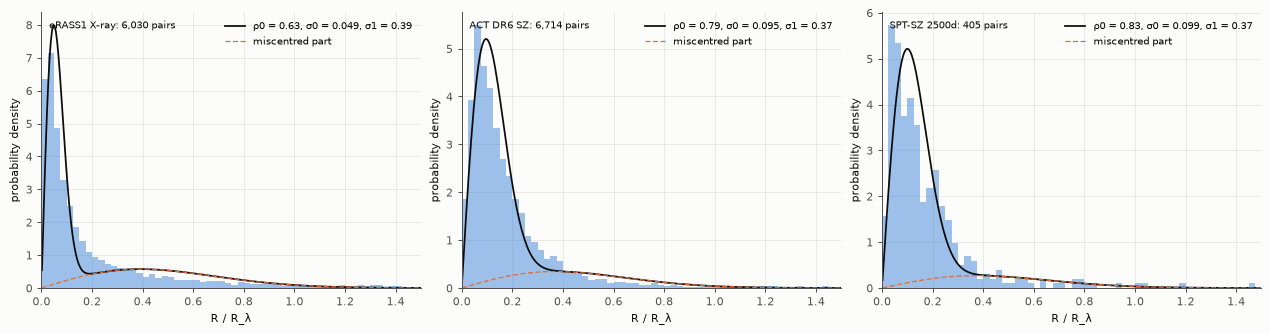

In [38]:
from scipy.optimize import minimize  # noqa: E402



def offsets(ref, xmax=1.5):
    """R/R_lambda of the rema clusters paired with the external clusters (and their indices)."""
    good = np.isfinite(ref["Z"]) & (ref["Z"] > 0.05)
    sub = np.flatnonzero(lam >= 20)
    ir = np.flatnonzero(good)
    a, b = match_within(ref["RA"][ir], ref["DEC"][ir], ref["Z"][ir], ra[sub], dec[sub], zl[sub], 10.0,
                        dz_max=0.05, rank2=lam[sub])
    i, r = sub[b], ir[a]
    sep = SkyCoord(ra[i] * u.deg, dec[i] * u.deg).separation(SkyCoord(ref["RA"][r] * u.deg, ref["DEC"][r] * u.deg))
    rmpc = sep.radian * COSMO.angular_diameter_distance(zl[i]).value * H        # h^-1 Mpc
    x = rmpc / rlam[i]
    keep = x < xmax
    return x[keep], i[keep], r[keep]


def fit_offsets(x, xmax=1.5):
    """Maximum-likelihood rho0, sigma0, sigma1 of the two-Rayleigh model, truncated at xmax."""
    def ray(x, s):
        return x / s**2 * np.exp(-0.5 * (x / s) ** 2) / (1 - np.exp(-0.5 * (xmax / s) ** 2))

    def nll(p):
        r0, s0, s1 = p
        if not (0 < r0 < 1 and 0.005 < s0 < s1 < 2):
            return 1e30
        return -np.sum(np.log(r0 * ray(x, s0) + (1 - r0) * ray(x, s1) + 1e-300))

    best = min((minimize(nll, p0_, method="Nelder-Mead") for p0_ in ([0.8, 0.05, 0.3], [0.6, 0.1, 0.5])),
               key=lambda r: r.fun)
    return best.x, ray


fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
fits = {}
for ax, (name, lab) in zip(axes, (("erass1", "eRASS1 X-ray"), ("act_dr6", "ACT DR6 SZ"), ("spt_2500d", "SPT-SZ 2500d"))):
    ref = external(name)
    if ref is None:
        ax.set_visible(False)
        continue
    x, i, r = offsets(ref)
    (r0, s0, s1), ray = fit_offsets(x)
    xs = np.linspace(0.002, 1.5, 300)
    ax.hist(x, bins=np.linspace(0, 1.5, 61), density=True, color=BLUE, alpha=0.45, lw=0)
    ax.plot(xs, r0 * ray(xs, s0) + (1 - r0) * ray(xs, s1), color=INK, lw=1.4,
            label=f"ρ0 = {r0:.2f}, σ0 = {s0:.3f}, σ1 = {s1:.2f}")
    ax.plot(xs, (1 - r0) * ray(xs, s1), color=ORANGE, lw=1.0, ls=(0, (4, 2)), label="miscentred part")
    ax.set_xlabel("R / R_λ")
    ax.set_ylabel("probability density")
    ax.legend(loc="upper right")
    panel_label(ax, f"{lab}: {x.size:,} pairs")
    ax.set_xlim(0, 1.5)
    fits[name] = (r0, s0, s1, x.size)
    record(f"centring_{name}", [round(float(r0), 3), round(float(s0), 4), round(float(s1), 3), int(x.size)])
    print(f"{lab}: {x.size} pairs, rho0 = {r0:.2f}, sigma0 = {s0:.3f}, sigma1 = {s1:.2f}; "
          f"<P_cen> of the paired clusters {p0[i].mean():.2f}")
save(fig, "centering_offsets")

### Offsets from other redMaPPer centres (Zhang et al. 2019 Fig. 1)

The same pairing with the DES Y1 and SDSS DR8 redMaPPer catalogues: the fraction of clusters
whose central galaxy is the same (offset below 0.02 R_λ, a few arcseconds) measures how
reproducible the centring is between surveys of different depth and filters.

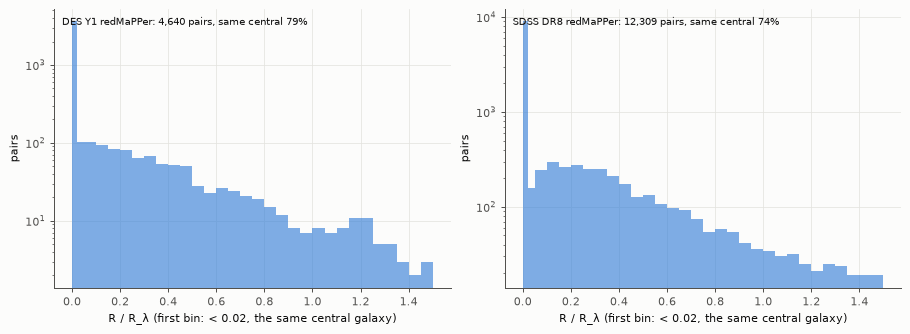

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for ax, (name, lab) in zip(axes, (("des_y1", "DES Y1 redMaPPer"), ("sdss_dr8", "SDSS DR8 redMaPPer"))):
    ref = external(name)
    if ref is None:
        ax.set_visible(False)
        continue
    sel = ref["LAMBDA"] >= 20
    ref = {k: v[sel] for k, v in ref.items()}
    x, i, r = offsets(ref)
    same = np.mean(x < 0.02)
    ax.hist(x, bins=np.r_[0, 0.02, np.arange(0.05, 1.501, 0.05)], color=BLUE, alpha=0.6, lw=0)
    ax.set_yscale("log")
    ax.set_xlabel("R / R_λ (first bin: < 0.02, the same central galaxy)")
    ax.set_ylabel("pairs")
    panel_label(ax, f"{lab}: {x.size:,} pairs, same central {same:.0%}")
    record(f"centring_same_{name}", [float(same), int(x.size)])
save(fig, "centering_optical")

## Comparison with SZ, X-ray and optical catalogues

External clusters are counted when they fall in the run footprint (a map pixel at least
half covered) at 0.05 < z < 0.9. A cluster is recovered when a rema cluster with λ ≥ 5 lies
within 1 h⁻¹ Mpc (projected at the external redshift) with |z_λ − z|/(1+z) < 0.05; the
richest such cluster is the counterpart.

In [40]:
cl = load("clusters")
mp = load("maps", ["PIX", "AREA"])
NSIDE = meta()["nside"]
lam, zl = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"])
ra, dec = np.asarray(cl["RA"]), np.asarray(cl["DEC"])
pix, parea = np.asarray(mp["PIX"]), np.asarray(mp["AREA"])
full = hp.nside2pixarea(NSIDE, degrees=True)


def in_run(r, d):
    p = hp.ang2pix(NSIDE, r, d, lonlat=True, nest=True)
    j = np.searchsorted(pix, p).clip(0, pix.size - 1)
    return (pix[j] == p) & (parea[j] > 0.5 * full)


def counterparts(ref, lam_min=5.0, dz_max=0.05, rmax=1.0):
    """Indices (external, rema) of the recovered clusters and the mask of those considered."""
    zz = ref["Z"]
    consider = np.isfinite(zz) & (zz > 0.05) & (zz < 0.9) & in_run(ref["RA"], ref["DEC"])
    if "PCONT" in ref:
        consider &= ref["PCONT"] < 0.5
    ie = np.flatnonzero(consider)
    sub = np.flatnonzero(lam >= lam_min)
    a, b, _ = match_physical(ref["RA"][ie], ref["DEC"][ie], zz[ie], ra[sub], dec[sub], zl[sub], rmax=rmax,
                             dz_max=dz_max, rank2=lam[sub])
    return ie[a], sub[b], consider


CATS = [("act_dr6", "ACT DR6 (SZ)"), ("act_dr5", "ACT DR5 (SZ)"), ("spt_2500d", "SPT-SZ 2500d"),
        ("psz2", "Planck PSZ2"), ("erass1", "eRASS1 (PCONT < 0.5)"), ("mcxc", "MCXC (X-ray)")]
REFS = {k: external(k) for k, _ in CATS}
CATS = [(k, lab) for k, lab in CATS if REFS[k] is not None]

### Recovery of SZ- and X-ray-selected clusters (Kluge et al. 2024 Fig. 10; Rozo & Rykoff 2014 Fig. 4)

Top: redshift distribution of the external clusters in the footprint (lines) and of the
recovered ones (filled). Bottom: the recovered fraction against redshift (left) and against
the external mass M500 (right; each catalogue's own mass scale).

ACT DR6 (SZ): 7,924 in the footprint at 0.05 < z < 0.9, recovered 92.6%


ACT DR5 (SZ): 3,670 in the footprint at 0.05 < z < 0.9, recovered 93.5%


SPT-SZ 2500d: 441 in the footprint at 0.05 < z < 0.9, recovered 95.2%


Planck PSZ2: 634 in the footprint at 0.05 < z < 0.9, recovered 88.8%


eRASS1 (PCONT < 0.5): 9,548 in the footprint at 0.05 < z < 0.9, recovered 87.4%


MCXC (X-ray): 883 in the footprint at 0.05 < z < 0.9, recovered 87.5%


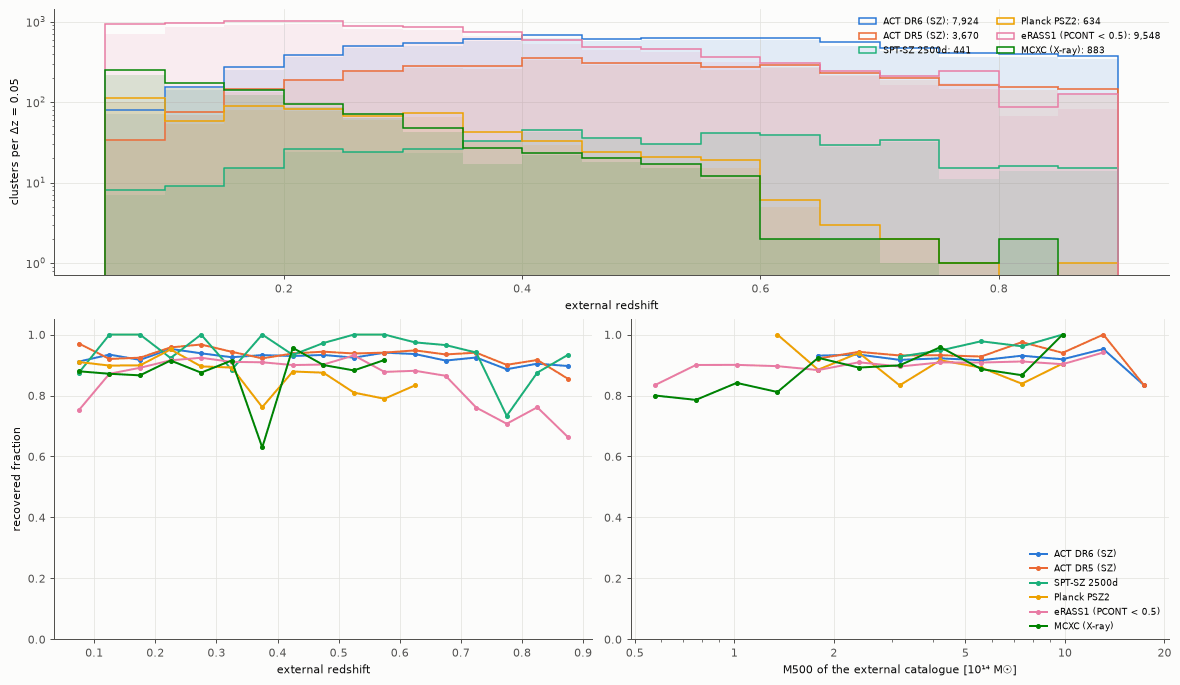

In [41]:
fig = plt.figure(figsize=(13, 7.5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])
axes = np.array([[fig.add_subplot(gs[0, :]), None], [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])
zb = np.arange(0.05, 0.901, 0.05)
mb = np.logspace(np.log10(0.5), np.log10(20), 14)
for k, (name, lab) in enumerate(CATS):
    ref = REFS[name]
    ie, ir, consider = counterparts(ref)
    col = SERIES[k]
    rec = np.zeros(ref["RA"].size, bool)
    rec[ie] = True
    axes[0, 0].hist(ref["Z"][consider], zb, histtype="step", color=col, lw=1.2, label=f"{lab}: {consider.sum():,}")
    axes[0, 0].hist(ref["Z"][rec], zb, color=col, alpha=0.12)
    hz_all = np.histogram(ref["Z"][consider], zb)[0]
    hz_rec = np.histogram(ref["Z"][rec], zb)[0]
    with np.errstate(divide="ignore", invalid="ignore"):
        f = np.where(hz_all >= 5, hz_rec / hz_all, np.nan)
    axes[1, 0].plot(0.5 * (zb[1:] + zb[:-1]), f, color=col, marker="o", ms=3, label=lab)
    if "M500" in ref:
        m = ref["M500"]
        okm = consider & np.isfinite(m) & (m > 0)
        hm_all = np.histogram(m[okm], mb)[0]
        hm_rec = np.histogram(m[okm & rec], mb)[0]
        with np.errstate(divide="ignore", invalid="ignore"):
            axes[1, 1].plot(np.sqrt(mb[1:] * mb[:-1]), np.where(hm_all >= 5, hm_rec / hm_all, np.nan), color=col,
                            marker="o", ms=3, label=lab)
    frac = rec[consider].mean()
    print(f"{lab}: {consider.sum():,} in the footprint at 0.05 < z < 0.9, recovered {frac:.1%}")
    record(f"recovery_{name}", [float(frac), int(consider.sum())])
axes[0, 0].set_xlabel("external redshift")
axes[0, 0].set_ylabel("clusters per Δz = 0.05")
axes[0, 0].set_yscale("log")
axes[0, 0].legend(fontsize=7, ncol=2)
axes[1, 0].set_xlabel("external redshift")
axes[1, 0].set_ylabel("recovered fraction")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 1].set_xscale("log")
plain_log_ticks(axes[1, 1])
axes[1, 1].set_xlabel("M500 of the external catalogue [10¹⁴ M☉]")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend(fontsize=7, loc="lower right")
save(fig, "external_recovery")

### Redshift consistency (Kluge et al. 2024 Fig. 7)

The external clusters with a spectroscopic or literature redshift (ACT DR6, SPT, MCXC), paired
by position only (1 h⁻¹ Mpc, the richest rema cluster with |Δz|/(1+z) < 0.3): fraction whose
z_λ agrees within 0.02, 0.03, 0.05 or 0.10 (in |Δz|/(1+z)), against λ.

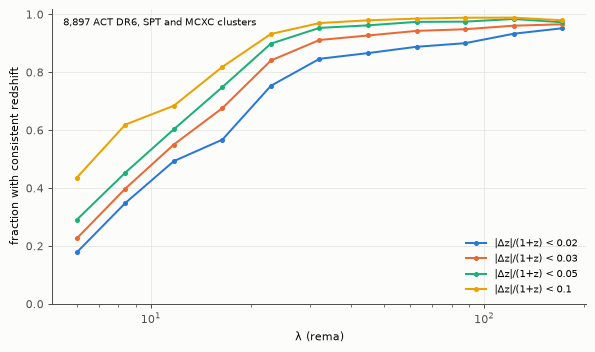

In [42]:
pairs = []
for name in ("act_dr6", "spt_2500d", "mcxc"):
    ref = REFS.get(name)
    if ref is None:
        continue
    ie, ir, _ = counterparts(ref, dz_max=0.3)
    pairs.append((ref["Z"][ie], ir))
zref = np.concatenate([p[0] for p in pairs])
irem = np.concatenate([p[1] for p in pairs])
dz = np.abs(zl[irem] - zref) / (1 + zref)
lb = np.logspace(np.log10(5), np.log10(200), 12)
fig, ax = plt.subplots(figsize=(6.5, 3.8), constrained_layout=True)
for k, tol in enumerate((0.02, 0.03, 0.05, 0.10)):
    b = binned(lam[irem], (dz < tol).astype(float), lb, min_n=10)
    ax.plot(b["x"], b["mean"], color=SERIES[k], marker="o", ms=3, label=f"|Δz|/(1+z) < {tol}")
    record(f"zcons_{tol}_lam20", float(np.mean(dz[lam[irem] >= 20] < tol)))
ax.set_xscale("log")
ax.set_xlabel("λ (rema)")
ax.set_ylabel("fraction with consistent redshift")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
panel_label(ax, f"{irem.size:,} ACT DR6, SPT and MCXC clusters")
save(fig, "external_zconsistency")

### Richness against mass proxies (Rozo et al. 2015 Fig. 2; Saro et al. 2015 Fig. 4; Bleem et al. 2020 Fig. 9)

λ of the counterparts against the SZ masses of ACT DR6 and SPT (M500c), the eRASS1 masses
(from the count rate, Bulbul et al. 2024) and the eRASS1 0.2–2.3 keV luminosity L500. The
line is a least-squares fit of ln λ on ln M (or ln L) for clusters at 0.1 < z < 0.6; the
scatter quoted is the rms of ln λ about it.

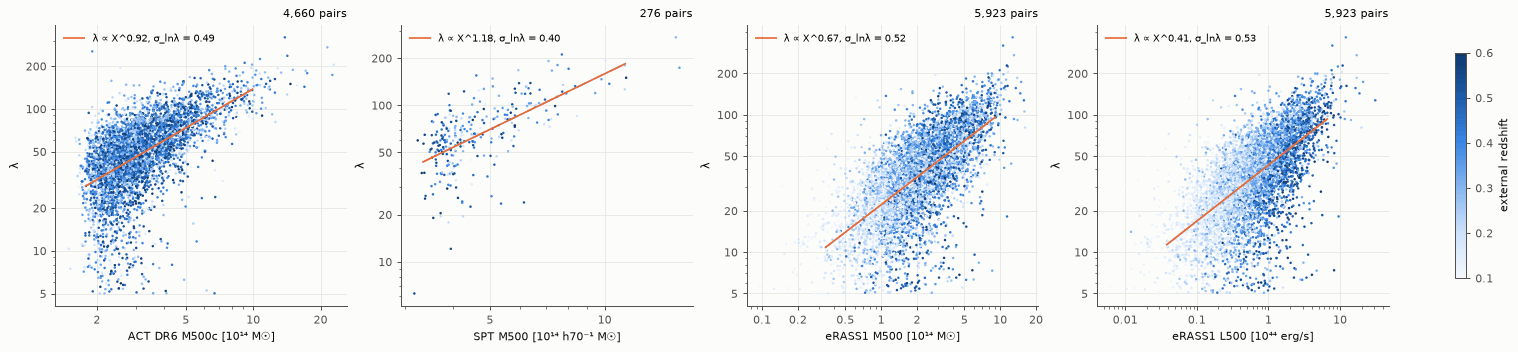

In [43]:
panels = [("act_dr6", "M500", "ACT DR6 M500c [10¹⁴ M☉]"), ("spt_2500d", "M500", "SPT M500 [10¹⁴ h70⁻¹ M☉]"),
          ("erass1", "M500", "eRASS1 M500 [10¹⁴ M☉]"), ("erass1", "LX", "eRASS1 L500 [10⁴⁴ erg/s]")]
panels = [p for p in panels if REFS.get(p[0]) is not None]
fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 3.8), constrained_layout=True, squeeze=False)
for ax, (name, col, label) in zip(axes[0], panels):
    ref = REFS[name]
    ie, ir, _ = counterparts(ref)
    x = ref[col][ie]
    ok = np.isfinite(x) & (x > 0) & (ref["Z"][ie] > 0.1) & (ref["Z"][ie] < 0.6)
    lx, ly = np.log(x[ok]), np.log(lam[ir][ok])
    slope, icpt = np.polyfit(lx, ly, 1)
    rms = np.std(ly - (slope * lx + icpt))
    sc = ax.scatter(x[ok], lam[ir][ok], s=4, c=ref["Z"][ie][ok], cmap=RAMP, vmin=0.1, vmax=0.6, lw=0,
                    rasterized=True)
    xs = np.logspace(np.log10(np.percentile(x[ok], 1)), np.log10(np.percentile(x[ok], 99)), 20)
    ax.plot(xs, np.exp(icpt) * xs ** slope, color=ORANGE, lw=1.4,
            label=f"λ ∝ X^{slope:.2f}, σ_lnλ = {rms:.2f}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    plain_log_ticks(ax, "x", subs=(1.0,) if col == "LX" else (1.0, 2.0, 5.0))
    plain_log_ticks(ax, "y")
    ax.set_xlabel(label)
    ax.set_ylabel("λ")
    ax.legend(loc="upper left")
    ax.set_title(f"{ok.sum():,} pairs", loc="right")
    record(f"lam_{name}_{col}", [round(float(slope), 3), round(float(rms), 3), int(ok.sum())])
fig.colorbar(sc, ax=axes[0, :], label="external redshift", shrink=0.8)
save(fig, "external_mass")

### Wen & Han (2024) clusters (Wen & Han 2024 Fig. 10; Zou et al. 2021 Fig. 9)

Wen & Han (2024) found 1.58 million clusters in the Legacy Surveys DR9 and DR10 from the
stellar mass of galaxies in photometric-redshift slices. Left: fraction of rema clusters
with a Wen & Han counterpart (1 h⁻¹ Mpc, |Δz|/(1+z) < 0.05) against λ, in bins of z_λ. Right:
fraction of Wen & Han clusters in the footprint with a rema counterpart (λ ≥ 5) against their
mass M500, in bins of redshift.

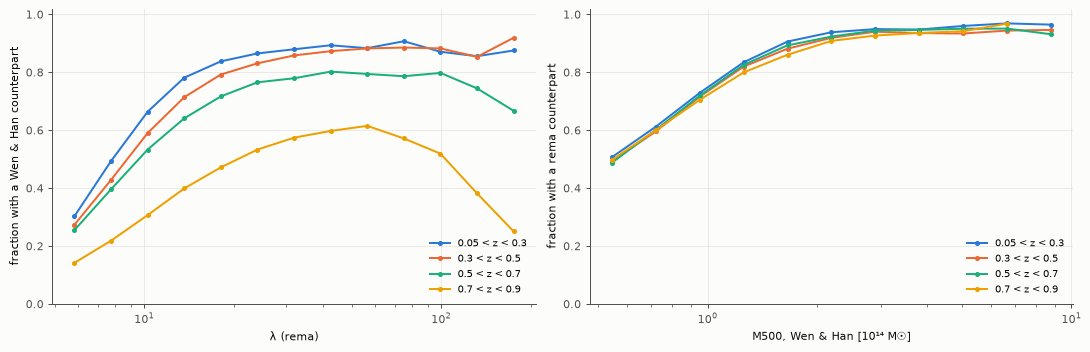

rema lambda >= 20 with a Wen & Han counterpart: 70.8%; Wen & Han M500 >= 2e14 with a rema counterpart: 93.2%


In [44]:
wh = external("wen_han_2024")
if wh is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
    inside = in_run(wh["RA"], wh["DEC"]) & np.isfinite(wh["Z"]) & (wh["Z"] > 0.05) & (wh["Z"] < 0.9)
    iw = np.flatnonzero(inside)
    sub = np.flatnonzero(lam >= 5)
    a, b, _ = match_physical(ra[sub], dec[sub], zl[sub], wh["RA"][iw], wh["DEC"][iw], wh["Z"][iw], rmax=1.0,
                             dz_max=0.05, rank2=wh["M500"][iw])
    has_wh = np.zeros(lam.size, bool)
    has_wh[sub[a]] = True
    has_rm = np.zeros(wh["RA"].size, bool)
    has_rm[iw[b]] = True
    lb = np.logspace(np.log10(5), np.log10(200), 14)
    mb = np.logspace(np.log10(0.47), np.log10(10), 12)
    for k, (z0, z1) in enumerate(((0.05, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9))):
        s = (zl >= z0) & (zl < z1) & (lam >= 5)
        bb = binned(lam[s], has_wh[s].astype(float), lb, min_n=20)
        axes[0].plot(bb["x"], bb["mean"], color=SERIES[k], marker="o", ms=3, label=f"{z0} < z < {z1}")
        s = inside & (wh["Z"] >= z0) & (wh["Z"] < z1)
        bb = binned(wh["M500"][s], has_rm[s].astype(float), mb, min_n=20)
        axes[1].plot(bb["x"], bb["mean"], color=SERIES[k], marker="o", ms=3, label=f"{z0} < z < {z1}")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("λ (rema)")
    axes[0].set_ylabel("fraction with a Wen & Han counterpart")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("M500, Wen & Han [10¹⁴ M☉]")
    axes[1].set_ylabel("fraction with a rema counterpart")
    for ax in axes:
        ax.set_ylim(0, 1.02)
        ax.legend(loc="lower right")
    save(fig, "external_wenhan")
    record("wh_frac_lam20", float(has_wh[lam >= 20].mean()))
    record("wh_frac_m2", float(has_rm[inside & (wh["M500"] >= 2)].mean()))
    print(f"rema lambda >= 20 with a Wen & Han counterpart: {has_wh[lam >= 20].mean():.1%}; "
          f"Wen & Han M500 >= 2e14 with a rema counterpart: {has_rm[inside & (wh['M500'] >= 2)].mean():.1%}")

## Members

The member catalogue lists every galaxy with a membership probability P ≥ 0.01 (P = PMEM ×
θ_L × θ_R: colour, luminosity and radial weights) and the centre candidates. The reduced
table of `prepare.py` keeps P ≥ 0.05 and every member with a spectroscopic redshift.
`VEL` is the rest-frame velocity relative to the velocity-clipped cluster redshift, and
`ISMEMBER_SPEC` flags the members kept by the 3σ clipping (Clerc et al. 2016).

In [45]:
cl = load("clusters")
mem = load("members")
lam, zl = np.asarray(cl["LAMBDA"]), np.asarray(cl["Z_LAMBDA"])
row, P = np.asarray(mem["CL_ROW"]), np.asarray(mem["P"])
zsp, vel, kept = np.asarray(mem["ZSPEC"]), np.asarray(mem["VEL"]), np.asarray(mem["ISMEMBER_SPEC"]).astype(bool)
rlam = np.asarray(cl["R_LAMBDA"])
x = np.asarray(mem["R"]) / rlam[row]
print(f"{P.size:,} members in the reduced table, {np.sum(zsp > 0):,} with a spectroscopic redshift")

69,582,559 members in the reduced table, 2,062,993 with a spectroscopic redshift


### An example cluster (Rykoff et al. 2014 Fig. 16; Kluge et al. 2024 Fig. 4)

The cluster with the most spectroscopic members among those with λ ≥ 80 at 0.1 < z_λ < 0.3,
outside the calibration area. (a) members on the sky, coloured by P, with the R_λ circle
and the centre candidates labelled with P_cen; (b) P(z) with z_λ, the velocity-clipped
spectroscopic redshift and that of the central; (c) distribution of P; (d) Σ P within R
against the NFW filter of the richness (normalised to λ at R_λ); (e) rest-frame velocities
of the spectroscopic members with the clipping limits ±3σ_v.

example: rema J213.600-00.378, lambda = 116.3 ± 4.6, z_lambda = 0.1379, 134 spectroscopic members, sigma_v = 826 km/s


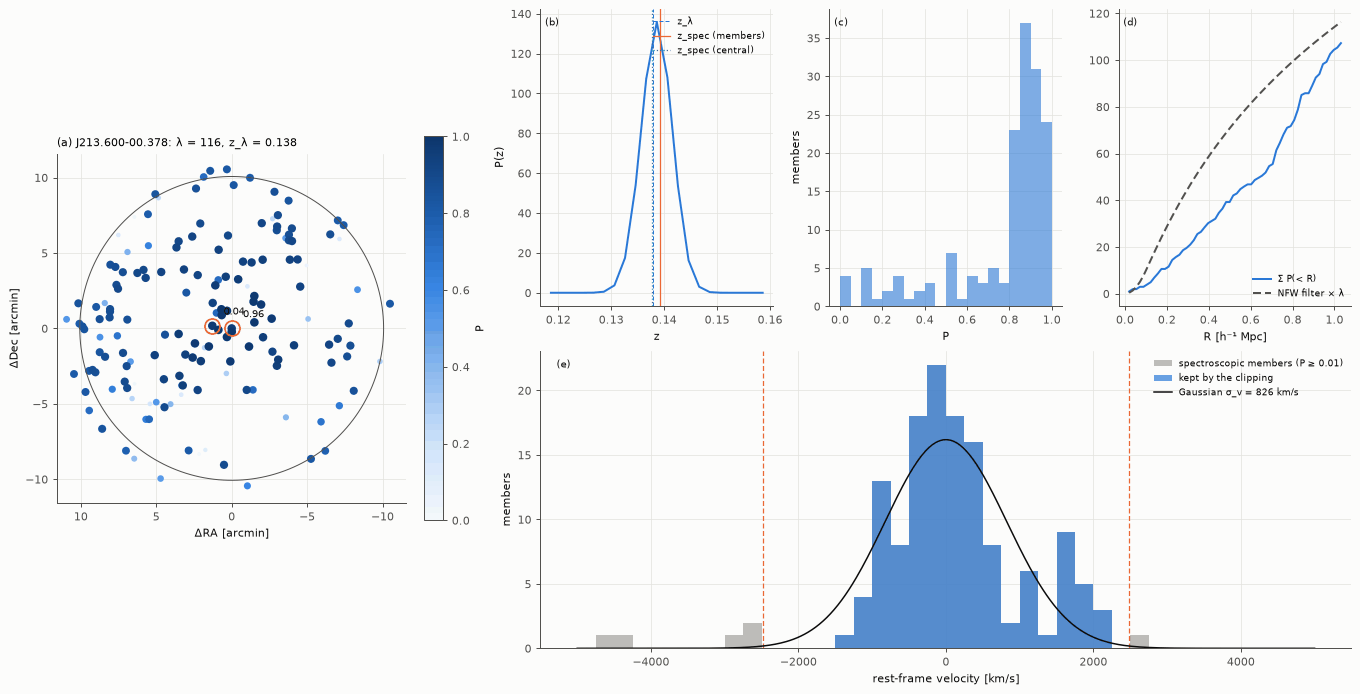

In [46]:
nmem = np.asarray(cl["N_MEMBERS"])
cand = np.flatnonzero((lam >= 80) & (zl > 0.1) & (zl < 0.3) & ~np.asarray(cl["IN_CALIB"]))
c = cand[np.argmax(nmem[cand])]
ra0, dec0, z0, rl = float(cl["RA"][c]), float(cl["DEC"][c]), float(zl[c]), float(rlam[c])
name = f"J{ra0:07.3f}{dec0:+07.3f}"
print(f"example: rema {name}, lambda = {lam[c]:.1f} ± {cl['LAMBDA_E'][c]:.1f}, z_lambda = {z0:.4f}, "
      f"{nmem[c]} spectroscopic members, sigma_v = {cl['VDISP_BOOT'][c]:.0f} km/s")
mine = np.flatnonzero(row == c)


def nfw_sigma_np(r, rs=0.15, rcore=0.1):
    """Projected NFW shape F(x) of the richness filter (flat inside rcore), r in h^-1 Mpc (numpy
    version of rema.model.profiles.nfw_sigma)."""
    x = np.maximum(np.asarray(r, np.float64), rcore) / rs
    out = np.full(x.shape, 1.0 / 3.0)
    lo, hi = x < 0.999, x > 1.001
    out[lo] = (1 - np.arccosh(1 / x[lo]) / np.sqrt(1 - x[lo] ** 2)) / (x[lo] ** 2 - 1)
    out[hi] = (1 - np.arccos(1 / x[hi]) / np.sqrt(x[hi] ** 2 - 1)) / (x[hi] ** 2 - 1)
    return out


def nfw_enclosed_np(r, rs=0.15, rcore=0.1):
    """Integral of 2 pi R nfw_sigma_np(R) from 0 to r (numerical)."""
    g = np.linspace(0, np.max(r), 4001)
    cum = np.concatenate([[0], np.cumsum(0.5 * np.diff(g) * (2 * np.pi * g * nfw_sigma_np(g, rs, rcore))[1:]
                                          + 0.5 * np.diff(g) * (2 * np.pi * g * nfw_sigma_np(g, rs, rcore))[:-1])])
    return np.interp(r, g, cum)


fig = plt.figure(figsize=(15, 7.6), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1.5, 1, 1, 1])
ax = fig.add_subplot(gs[:, 0])
mra, mdec, mp = np.asarray(mem["RA"])[mine], np.asarray(mem["DEC"])[mine], P[mine]
dx = (mra - ra0) * np.cos(np.radians(dec0)) * 60
dy = (mdec - dec0) * 60
order = np.argsort(mp)
sc = ax.scatter(dx[order], dy[order], c=mp[order], s=8 + 40 * mp[order], cmap=RAMP, vmin=0, vmax=1, lw=0)
mpc_arcmin = np.radians(1 / 60) * COSMO.angular_diameter_distance(z0).value * H
t = np.linspace(0, 2 * np.pi, 200)
ax.plot(rl / mpc_arcmin * np.cos(t), rl / mpc_arcmin * np.sin(t), color=INK2, lw=0.8)
rac, decc, pc = np.asarray(cl["RA_CENT"])[c], np.asarray(cl["DEC_CENT"])[c], np.asarray(cl["P_CEN"])[c]
for k in range(len(pc)):
    if pc[k] > 0.01:
        cx, cy = (rac[k] - ra0) * np.cos(np.radians(dec0)) * 60, (decc[k] - dec0) * 60
        ax.plot(cx, cy, "o", mfc="none", mec=ORANGE, ms=12, mew=1.4)
        ax.annotate(f"{pc[k]:.2f}", (cx, cy), xytext=(9, 9), textcoords="offset points", fontsize=8, color=INK)
ax.set_aspect("equal")
lim = 1.15 * rl / mpc_arcmin
ax.set_xlim(lim, -lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("ΔRA [arcmin]")
ax.set_ylabel("ΔDec [arcmin]")
fig.colorbar(sc, ax=ax, shrink=0.6, label="P")
ax.set_title(f"(a) {name}: λ = {lam[c]:.0f}, z_λ = {z0:.3f}", loc="left")
ax = fig.add_subplot(gs[0, 1])
pzb, pz = np.asarray(cl["PZBINS"])[c], np.asarray(cl["PZ"])[c]
ax.plot(pzb, pz / np.trapezoid(pz, pzb), color=BLUE)
ax.axvline(z0, color=BLUE, lw=0.8, ls=(0, (4, 2)), label="z_λ")
ax.axvline(cl["SPEC_Z_BOOT"][c], color=ORANGE, lw=1.0, label="z_spec (members)")
ax.axvline(cl["CG_SPEC_Z"][c], color=AQUA, lw=1.0, ls=":", label="z_spec (central)")
ax.set_xlabel("z")
ax.set_ylabel("P(z)")
ax.legend(fontsize=7, loc="upper right")
panel_label(ax, "(b)")
ax = fig.add_subplot(gs[0, 2])
ax.hist(mp, bins=np.linspace(0, 1, 21), color=BLUE, alpha=0.6)
ax.set_xlabel("P")
ax.set_ylabel("members")
panel_label(ax, "(c)")
ax = fig.add_subplot(gs[0, 3])
rm = np.asarray(mem["R"])[mine]
rg = np.linspace(0.02, rl, 60)
ax.plot(rg, [mp[rm < r].sum() for r in rg], color=BLUE, label="Σ P(< R)")
nfw = nfw_enclosed_np(rg) / nfw_enclosed_np(np.array([rl]))[0] * lam[c]
ax.plot(rg, nfw, color=INK2, ls=(0, (4, 2)), label="NFW filter × λ")
ax.set_xlabel("R [h⁻¹ Mpc]")
ax.legend(fontsize=7)
panel_label(ax, "(d)")
ax = fig.add_subplot(gs[1, 1:])
spec = mine[zsp[mine] > 0]
v = vel[spec]
sig = float(cl["VDISP_BOOT"][c])
bins = np.arange(-5000, 5001, 250)
ax.hist(v[np.isfinite(v)], bins, color=MUTED, alpha=0.7, label="spectroscopic members (P ≥ 0.01)")
ax.hist(v[kept[spec]], bins, color=BLUE, alpha=0.7, label="kept by the clipping")
for s in (-3, 3):
    ax.axvline(s * sig, color=ORANGE, lw=1.0, ls=(0, (4, 2)))
vs = np.linspace(-5000, 5000, 400)
ax.plot(vs, kept[spec].sum() * 250 / (np.sqrt(2 * np.pi) * sig) * np.exp(-0.5 * (vs / sig) ** 2), color=INK,
        lw=1.2, label=f"Gaussian σ_v = {sig:.0f} km/s")
ax.set_xlabel("rest-frame velocity [km/s]")
ax.set_ylabel("members")
ax.legend(fontsize=7)
panel_label(ax, "(e)")
save(fig, "member_example")

### Membership probability against spectroscopic membership (Rozo et al. 2015b Fig. 8; Rines et al. 2018 Fig. 14)

Members with a spectroscopic redshift, in clusters with a velocity-clipped redshift and
dispersion (≥ 10 spectroscopic members, unflagged), excluding the central: the fraction kept
by the 3σ clipping in bins of P. If P is calibrated, the fraction follows the diagonal. The
spectroscopic targets are the bright galaxies of SDSS, BOSS and DESI, so the test covers the
bright end of the members.

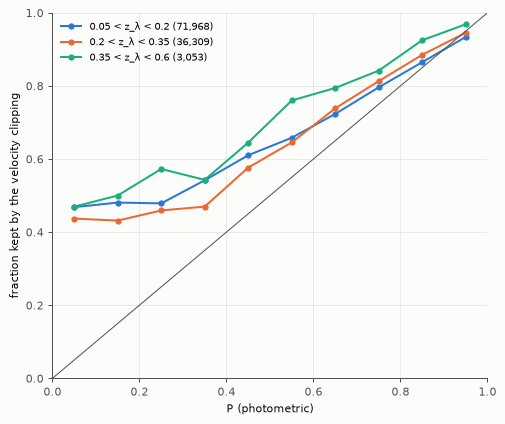

In [47]:
vflag = np.asarray(cl["VDISP_FLAG"]).astype(bool)
good_cl = (nmem >= 10) & ~vflag & np.isfinite(np.asarray(cl["VDISP_BOOT"]))
s = (zsp > 0) & good_cl[row] & (np.asarray(mem["CENT_RANK"]) != 0) & np.isfinite(vel)
pb = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(5.5, 4.6), constrained_layout=True)
for k, (z0_, z1_) in enumerate(((0.05, 0.2), (0.2, 0.35), (0.35, 0.6))):
    w = s & (zl[row] >= z0_) & (zl[row] < z1_)
    b = binned(P[w], kept[w].astype(float), pb, min_n=30)
    ax.plot(b["x"], b["mean"], color=SERIES[k], marker="o", ms=4, label=f"{z0_} < z_λ < {z1_} ({w.sum():,})")
ax.plot([0, 1], [0, 1], color=INK2, lw=0.8)
ax.set_xlabel("P (photometric)")
ax.set_ylabel("fraction kept by the velocity clipping")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
save(fig, "pmem_spec")
b = binned(P[s], kept[s].astype(float), pb, min_n=30)
record("pmem_spec_frac", [round(float(f), 3) for f in b["mean"]])

### Stacked velocities and projected fraction (Myles et al. 2021 Fig. 3)

P-weighted rest-frame velocities of the spectroscopic members (not the central) of the
clusters above, stacked in units of each cluster's σ_v, in bins of λ. A narrow Gaussian
(the cluster) plus a flat background within |v| < 5000 km/s is fitted to each stack; the
P-weighted fraction in the flat component estimates the fraction of members that are
projected along the line of sight.

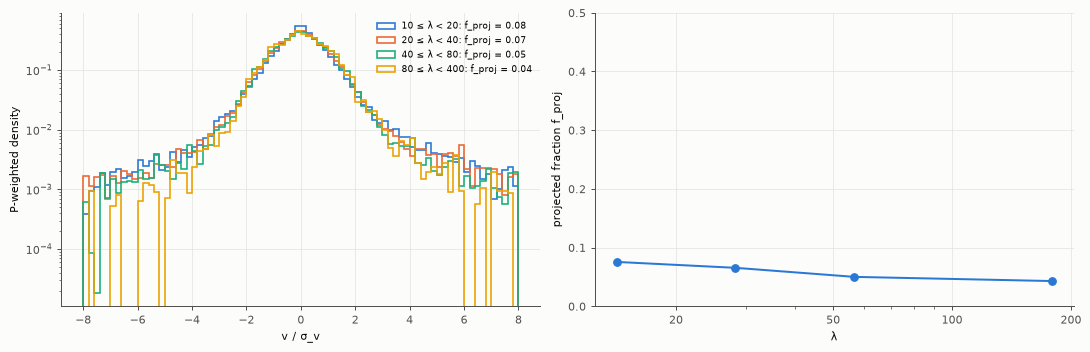

In [48]:
from scipy.optimize import minimize  # noqa: E402

VMAX = 5000.0
w = s & (np.abs(vel) < VMAX)
sv = np.asarray(cl["VDISP_BOOT"])[row]
lbins = [(10, 20), (20, 40), (40, 80), (80, 400)]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
fproj = []
for k, (l0, l1) in enumerate(lbins):
    q = w & (lam[row] >= l0) & (lam[row] < l1)
    vq, pq, sq = vel[q], P[q], sv[q]

    def nll(p, vq=vq, pq=pq, sq=sq):
        f, a = p
        if not (0 < f < 1 and 0.5 < a < 2):
            return 1e30
        g = np.exp(-0.5 * (vq / (a * sq)) ** 2) / (np.sqrt(2 * np.pi) * a * sq)
        return -np.sum(pq * np.log((1 - f) * g + f / (2 * VMAX)))

    res = minimize(nll, [0.2, 1.0], method="Nelder-Mead")
    f, a = res.x
    fproj.append((np.sqrt(l0 * l1), f, q.sum()))
    u_ = vq / sq
    axes[0].hist(u_, bins=np.linspace(-8, 8, 81), weights=pq, density=True, histtype="step", color=SERIES[k], lw=1.3,
                 label=f"{l0} ≤ λ < {l1}: f_proj = {f:.2f}")
axes[0].set_yscale("log")
axes[0].set_xlabel("v / σ_v")
axes[0].set_ylabel("P-weighted density")
axes[0].legend(fontsize=7)
fp = np.array(fproj)
axes[1].plot(fp[:, 0], fp[:, 1], color=BLUE, marker="o")
axes[1].set_xscale("log")
plain_log_ticks(axes[1])
axes[1].set_xlabel("λ")
axes[1].set_ylabel("projected fraction f_proj")
axes[1].set_ylim(0, 0.5)
save(fig, "member_projection")
record("fproj", [[round(float(a_), 1), round(float(b_), 3)] for a_, b_, _ in fproj])

### Radial profiles (Rykoff et al. 2014 Fig. 16; Tomooka et al. 2020 Fig. 2)

Left: stacked surface density of membership probability, Σ P per unit area in units of
R_λ, divided by λ, in bins of λ, with the NFW filter of the richness (r_s = 0.15 h⁻¹ Mpc,
for the median R_λ of each bin). Right: fraction of the spectroscopic members (P ≥ 0.05)
kept by the velocity clipping against R/R_λ.

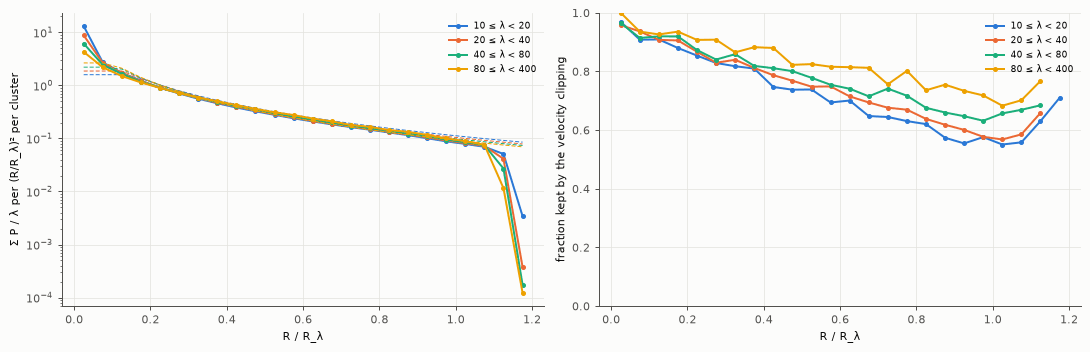

In [49]:
xb = np.linspace(0.0, 1.2, 25)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for k, (l0, l1) in enumerate(lbins):
    cls = (lam >= l0) & (lam < l1) & (zl > 0.1) & (zl < 0.6)
    q = cls[row]
    ssum = np.histogram(x[q], xb, weights=P[q] / lam[row[q]])[0]
    ann = np.pi * (xb[1:] ** 2 - xb[:-1] ** 2)
    prof = ssum / ann / cls.sum()
    xc = 0.5 * (xb[1:] + xb[:-1])
    axes[0].plot(xc, prof, color=SERIES[k], marker="o", ms=3, label=f"{l0} ≤ λ < {l1}")
    rl_med = np.median(rlam[cls])
    rr = xc * rl_med
    nf = nfw_sigma_np(rr)
    inner = xc < 1.0                                  # same integral inside R_lambda
    norm = np.sum((nf * ann)[inner]) / np.sum((prof * ann)[inner])
    axes[0].plot(xc, nf / norm, color=SERIES[k], lw=0.8, ls=(0, (4, 2)))
    q2 = q & (zsp > 0) & good_cl[row] & (np.asarray(mem["CENT_RANK"]) != 0)
    b = binned(x[q2], kept[q2].astype(float), xb, min_n=30)
    axes[1].plot(b["x"], b["mean"], color=SERIES[k], marker="o", ms=3, label=f"{l0} ≤ λ < {l1}")
axes[0].set_yscale("log")
axes[0].set_xlabel("R / R_λ")
axes[0].set_ylabel("Σ P / λ per (R/R_λ)² per cluster")
axes[0].legend(fontsize=7)
axes[1].set_xlabel("R / R_λ")
axes[1].set_ylabel("fraction kept by the velocity clipping")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7)
save(fig, "member_profiles")